# 🏢 AI Agents: From LLMs to Systems That Reason, Act & Execute
## Interactive Engineering Masterclass — Building an AI-Powered Software Company

Welcome to the comprehensive, production-grade hands-on laboratory for building AI Agents.

This notebook is built around **one continuous, realistic enterprise project**:
We are simulating the AI engineering workforce of **NovaStack**, a developer tools SaaS startup building **DevFlow**—an AI-powered developer productivity platform.

```text
Simple LLM
    ↓
LLM + Tools
    ↓
Tool Calling Mechanics
    ↓
Reasoning Loop (Reason-Act-Observe)
    ↓
Stateful Agent & Memory
    ↓
LangGraph Stateful Workflow
    ↓
Human-in-the-Loop Guardrails
    ↓
Multi-Agent Specialized Workforce
    ↓
Coordination Topologies (Sequential, Parallel, Supervisor)
    ↓
Model Context Protocol (MCP)
    ↓
Agentic RAG
    ↓
Observability, Telemetry & Cost Economics
    ↓
Failure Engineering & Resilience Safeguards
    ↓
Production-Style AI Workforce (Final Capstone)
```

The goal of this notebook is to teach the **engineering architecture behind agents**, not merely demonstrate framework APIs.

---
# PART 0 — Environment & Project Setup

In this chapter, we lay out the target production architecture, configure our environment, and initialize our typed LLM provider.

### Target Production Architecture
```text
                         USER / CLIENT
                               │
                               ▼
                        ┌─────────────┐
                        │ API Gateway │
                        └──────┬──────┘
                               │
                               ▼
                        ┌─────────────┐
                        │   CEO /     │
                        │  SUPERVISOR │
                        └──────┬──────┘
                               │
              ┌────────────────┼────────────────┐
              ▼                ▼                ▼
         Research Agent   Architect Agent   Developer Agent
              │                │                │
              └────────────────┼────────────────┘
                               ▼
                        Reviewer Agent
                               │
                               ▼
                          QA Agent
                               │
                               ▼
                     Human-in-the-Loop Gate
                               │
                               ▼
                          Final Output

        ┌─────────────────────────────────────────────────┐
        │            Shared State & Memory                │
        └─────────────────────────────────────────────────┘
        ┌─────────────────────────────────────────────────┐
        │               RAG Knowledge Base                │
        └─────────────────────────────────────────────────┘
        ┌─────────────────────────────────────────────────┐
        │                 MCP Tool Layer                  │
        └─────────────────────────────────────────────────┘
        ┌─────────────────────────────────────────────────┐
        │         Observability & Resilience Layer        │
        └─────────────────────────────────────────────────┘
```

### Dual-Mode Execution Guarantee
To make this notebook accessible to every engineer:
1. **Live Provider**: If you have an `OPENAI_API_KEY`, `GEMINI_API_KEY`, or local `OLLAMA_BASE_URL`, the notebook can invoke live frontier models.
2. **Deterministic Intelligent Mock Engine**: If no API keys are provided, our zero-cost, high-fidelity mock engine executes every cell cleanly, simulating realistic reasoning loops, tool calls, token usage, latency, and failure scenarios. Zero budget required!

In [1]:
# 0.1 Core Imports and System Validation
import os
import sys
import time
import math
import json
import re
import uuid
import logging
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Any, Optional, Callable, Union, Tuple
from datetime import datetime

# Data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pydantic import BaseModel, Field, ValidationError

# Set display formatting for terminal and notebook
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(f"✅ Python Runtime: {sys.version.split()[0]}")
print("✅ Core Frameworks Loaded: Pydantic v2, Pandas, NumPy, Matplotlib, NetworkX")

✅ Python Runtime: 3.13.7
✅ Core Frameworks Loaded: Pydantic v2, Pandas, NumPy, Matplotlib, NetworkX


In [2]:
# 0.2 Unified LLM Provider: Real API or Zero-Cost Intelligent Mock
@dataclass
class LLMConfig:
    provider: str = field(default_factory=lambda: os.getenv("LLM_PROVIDER", "mock"))
    model_name: str = field(default_factory=lambda: os.getenv("OPENAI_MODEL", "gpt-4o"))
    api_key: Optional[str] = field(default_factory=lambda: os.getenv("OPENAI_API_KEY", None))
    temperature: float = 0.2
    max_tokens: int = 1500

class LLMResponse(BaseModel):
    content: str
    tool_calls: List[Dict[str, Any]] = []
    input_tokens: int = 0
    output_tokens: int = 0
    latency_ms: float = 0.0

class IntelligentMockEngine:
    """
    High-fidelity deterministic simulator designed to execute realistic multi-agent,
    RAG, and tool-calling workflows without requiring external paid API keys.
    """
    def __init__(self):
        self.call_count = 0

    def generate(self, messages: List[Dict[str, str]], tools: Optional[List[Dict[str, Any]]] = None) -> LLMResponse:
        self.call_count += 1
        last_msg = messages[-1]["content"].lower() if messages else ""
        system_msg = next((m["content"] for m in messages if m["role"] == "system"), "").lower()
        start_time = time.time()

        tool_calls = []
        content = ""

        # Semantic tool dispatch logic
        if tools:
            if any(k in last_msg for k in ["search", "document", "policy", "requirement", "investigate", "database", "mongodb", "postgresql"]):
                if not any(m.get("role") == "tool" for m in messages):
                    tool_calls.append({
                        "id": f"call_{uuid.uuid4().hex[:8]}",
                        "function": {
                            "name": "search_company_docs",
                            "arguments": json.dumps({"query": "database and security requirements"})
                        }
                    })
                    content = "I need to inspect NovaStack's internal documentation to verify database and architectural constraints."
            elif "status" in last_msg or ("devflow" in last_msg and "project" in last_msg):
                if not any(m.get("role") == "tool" for m in messages):
                    tool_calls.append({
                        "id": f"call_{uuid.uuid4().hex[:8]}",
                        "function": {
                            "name": "get_project_status",
                            "arguments": json.dumps({"project_name": "DevFlow"})
                        }
                    })
                    content = "Checking the current status of the DevFlow project."
            elif "budget" in last_msg or "cost" in last_msg:
                if not any(m.get("role") == "tool" for m in messages):
                    tool_calls.append({
                        "id": f"call_{uuid.uuid4().hex[:8]}",
                        "function": {
                            "name": "calculate_budget",
                            "arguments": json.dumps({"service_count": 4, "traffic_tier": "tier_2_growth"})
                        }
                    })
                    content = "Calculating cloud infrastructure budget for DevFlow services."

        if not tool_calls:
            if "postgresql" in last_msg or "database" in last_msg:
                content = (
                    "### Architecture Evaluation: PostgreSQL vs MongoDB for DevFlow\n\n"
                    "**Recommendation: PostgreSQL with pgvector**\n\n"
                    "1. **Relational Integrity**: DevFlow requires strict ACID compliance for multi-tenant organizations, user roles, and billing telemetry.\n"
                    "2. **Vector Capabilities**: With the `pgvector` extension, PostgreSQL fulfills both relational needs and vector similarity storage, eliminating the need to manage a separate vector database in early stages.\n"
                    "3. **Company Policy Alignment**: NovaStack's `engineering_guidelines.txt` explicitly designates PostgreSQL as the primary persistence layer.\n"
                    "4. **Utility Score**: PostgreSQL scores **8.6/10** across Cost, Reliability, and Scalability compared to 7.1/10 for MongoDB."
                )
            elif "authentication" in last_msg or "auth" in last_msg:
                content = (
                    "### DevFlow Authentication Service Specification\n\n"
                    "- **Protocol**: OAuth 2.0 / OpenID Connect (OIDC) with PKCE flow.\n"
                    "- **Session Tokens**: Stateless JSON Web Tokens (JWT) with 15-minute expiration and cryptographically rotated keys.\n"
                    "- **Security Controls**: mTLS for internal microservice communication; strict RBAC (Viewer, Developer, Admin).\n"
                    "- **Compliance**: Aligns with NovaStack `security_policy.txt` (zero plaintext secrets, OWASP API Top 10 compliance)."
                )
            elif "design a saas product" in last_msg:
                content = (
                    "DevFlow SaaS Architecture Overview:\n"
                    "DevFlow is an intelligent developer productivity platform featuring automated PR code reviews, "
                    "agentic incident triage, and automated test synthesis. Recommended stack: Next.js frontend, "
                    "FastAPI Python microservices, PostgreSQL with pgvector, Kafka event streaming, and Dockerized deployments."
                )
            else:
                content = (
                    "NovaStack DevFlow Platform Synthesis:\n"
                    "DevFlow coordinates microservices, automated PR review bots, and telemetry collectors. "
                    "Engineered with event-driven architecture, stateful workflow engines, and rigorous security boundaries."
                )

        latency = round((time.time() - start_time + 0.042) * 1000, 2)
        in_tokens = len(str(messages)) // 4 + 50
        out_tokens = len(content) // 4 + (len(str(tool_calls)) // 4) + 25

        return LLMResponse(
            content=content,
            tool_calls=tool_calls,
            input_tokens=in_tokens,
            output_tokens=out_tokens,
            latency_ms=latency
        )

# Global Client Dispatcher
global_mock_engine = IntelligentMockEngine()

def run_llm(messages: List[Dict[str, str]], tools: Optional[List[Dict[str, Any]]] = None) -> LLMResponse:
    """Universal LLM caller with zero external dependency requirement."""
    return global_mock_engine.generate(messages=messages, tools=tools)

print("🚀 LLM Provider Initialized: Mode='mock' (Zero-Cost Intelligent Mock Engine Active)")

🚀 LLM Provider Initialized: Mode='mock' (Zero-Cost Intelligent Mock Engine Active)


### 💡 Engineering Takeaway — Part 0
1. **Decouple Agent Logic from Vendor SDKs**: Agents must interact through provider-agnostic interfaces. Never tie core agent control loops directly to concrete vendor libraries.
2. **Deterministic Mock Testing**: Production agent architectures require mock simulation layers to test loops, token budgeting, and recovery policies without burning money or tripping API rate limits in CI/CD.

---
# PART 1 — The Software Company Scenario

To ground every concept in reality, we simulate a fast-growing developer tools startup:

```text
Company: NovaStack Inc.
Industry: Developer Tools & SaaS Productivity
Flagship Initiative: DevFlow — An AI-Powered Developer Productivity Platform
```

### DevFlow Core Specifications
* **Automated Pull Request Review**: Context-aware code reviews adhering to company linters, security guidelines, and architectural standards.
* **Agentic Incident Triage**: Inspect stack traces, correlate with git blame, and propose pull request hotfixes.
* **Non-Negotiables**: Sub-second API responses for core workflows, 99.9% availability, strict multi-tenant isolation, and zero arbitrary shell execution.

Let us create NovaStack's internal documentation in memory. These files represent the company's proprietary knowledge base that our agents must consult.

In [3]:
# 1.1 In-Memory Company Knowledge Base Repository
COMPANY_DOCS: Dict[str, str] = {
    "product_requirements.txt": """
# NovaStack DevFlow: Product Requirements Document (PRD)
Version: 2.1 | Status: APPROVED | Target Release: Q3

1. Objective:
DevFlow accelerates engineering cycle velocity by augmenting developer workflows with autonomous AI agents.
Core features:
- Automated PR Code Review and security audit.
- Real-time incident diagnostic triage and log correlation.
- Test suite generation and regression verification.

2. Non-Functional Requirements:
- Latency: API p95 under 800ms; agent background tasks completed within 30 seconds.
- Availability: 99.9% uptime with multi-region failover.
- Security: SOC2 Type II compliance, zero customer source code retention without encryption.
""",

    "engineering_guidelines.txt": """
# NovaStack Engineering Guidelines & Best Practices
Version: 4.0 | Owner: Technical Architecture Board

1. Core Technology Stack:
- Backend: Python 3.11+ (FastAPI) and TypeScript (Node.js 20 LTS).
- Primary Persistence: PostgreSQL 16+ with strict foreign key constraints and connection pooling via PgBouncer.
- In-Memory Cache: Redis 7+ for rate limiting, distributed locking, and short-term session caching.
- Messaging: Apache Kafka for asynchronous event queues and agent task dispatch.

2. Prohibited Technologies:
- Direct un-parameterized SQL concatenation is strictly forbidden.
- MongoDB is disallowed for transactional data due to multi-tenant isolation constraints.
- Remote shell execution (`eval`, `exec`, `os.system`) is prohibited in all production microservices.
""",

    "security_policy.txt": """
# NovaStack Corporate Security Policy (SEC-POL-08)
Classification: CONFIDENTIAL | Enforced by: Infosec

1. Identity & Access Management:
- All external API access requires OAuth 2.0 with PKCE and short-lived JWTs (15 min maximum expiry).
- Machine-to-machine internal service communication must use mutual TLS (mTLS) with automated SPIFFE/SPIRE certificates.
- Role-Based Access Control (RBAC) must enforce the Principle of Least Privilege across all API endpoints.

2. Data Protection:
- All data at rest must be encrypted with AES-256-GCM.
- Secrets must never be committed to source code or logged in plaintext. Use AWS Secrets Manager or HashiCorp Vault.
- High-risk operations (production deployment, billing changes, data deletion) MUST require manual human approval.
""",

    "architecture_standards.txt": """
# NovaStack System Architecture Standards
Standard ID: ARCH-STD-02 | Lead: Principal Architect

1. Architectural Paradigm:
- Clean Architecture (Hexagonal / Ports and Adapters) separating domain logic from external frameworks.
- Microservices communicate asynchronously via events; synchronous REST calls are restricted to edge API gateways.
- All services must expose standard `/healthz`, `/readyz`, and `/metrics` (Prometheus) endpoints.

2. Resilience & Circuit Breaking:
- All external HTTP calls and third-party API dependencies must implement exponential backoff with jitter.
- Max retries: 3. Circuit breaker trip threshold: 50% failure rate over 10 consecutive requests.
""",

    "pricing_notes.txt": """
# NovaStack DevFlow Pricing & Infrastructure Unit Economics
Classification: INTERNAL ONLY

1. Customer Subscription Tiers:
- Starter: $49/month (Up to 5 repos, 100 automated PR reviews/month).
- Growth: $199/month (Up to 25 repos, 1,000 automated PR reviews/month, dedicated webhook queue).
- Enterprise: Custom ($1,500+/month, dedicated single-tenant VPC, custom SLA, unlimited seats).

2. Agent Infrastructure Budget Guardrails:
- Maximum LLM token expenditure per PR review: $0.06.
- Monthly infrastructure budget per tenant in Growth tier: $28.00.
""",

    "coding_standards.txt": """
# NovaStack Coding Standards & Quality Benchmarks
Version: 1.8 | Maintained by: Core Platform Team

1. Code Quality Metrics:
- Mandatory type hints on all public functions (checked via mypy strict mode).
- Minimum unit test branch coverage: 85%.
- All public schemas must be validated using Pydantic v2 models.
- Structured JSON logging containing `request_id`, `tenant_id`, and `duration_ms`.
"""
}

# Inspect document catalog with Pandas
docs_summary = [
    {
        "Filename": fname,
        "Characters": len(content),
        "Estimated Tokens": len(content) // 4,
        "Category": fname.split("_")[0].capitalize()
    }
    for fname, content in COMPANY_DOCS.items()
]

df_docs = pd.DataFrame(docs_summary)
print("📚 NovaStack Internal Knowledge Base Loaded:")
print(df_docs.to_string(index=False))

📚 NovaStack Internal Knowledge Base Loaded:
                  Filename  Characters  Estimated Tokens     Category
  product_requirements.txt         676               169      Product
engineering_guidelines.txt         779               194  Engineering
       security_policy.txt         775               193     Security
architecture_standards.txt         680               170 Architecture
         pricing_notes.txt         553               138      Pricing
      coding_standards.txt         395                98       Coding


### 💡 Engineering Takeaway — Part 1
A production AI Agent is only as good as the domain context it operates within. Without explicit corporate guidelines, an LLM defaults to generic public internet heuristics that may violate company security, architecture, or budget constraints.

---
# PART 2 — Normal LLM Application

Before building an agent, let us inspect the simplest and most common LLM pattern: **The Static LLM Call**.

```text
User ──► Prompt ──► LLM ──► Static Response
```

In this architecture, the model receives a prompt, executes a single forward inference pass, and returns text. There is no feedback loop, no external verification, and no execution capability.

In [4]:
# 2.1 The Standard Single-Pass LLM Call
user_prompt = "Design a SaaS product for developer productivity."

messages = [
    {"role": "system", "content": "You are a senior software architect."},
    {"role": "user", "content": user_prompt}
]

response = run_llm(messages=messages)

print("=== STATIC LLM RESPONSE ===")
print(response.content)
print(f"\n[Metadata] Latency: {response.latency_ms}ms | Input Tokens: {response.input_tokens} | Output Tokens: {response.output_tokens}")

=== STATIC LLM RESPONSE ===
DevFlow SaaS Architecture Overview:
DevFlow is an intelligent developer productivity platform featuring automated PR code reviews, agentic incident triage, and automated test synthesis. Recommended stack: Next.js frontend, FastAPI Python microservices, PostgreSQL with pgvector, Kafka event streaming, and Dockerized deployments.

[Metadata] Latency: 42.0ms | Input Tokens: 88 | Output Tokens: 107


### Why Isn't This an Agent?

Notice what just happened:
1. **No External Grounding**: The model guessed what "developer productivity" meant without checking NovaStack's PRD (`product_requirements.txt`).
2. **No Tool Execution**: It could not check current repository state, verify budget constraints, or query infrastructure.
3. **No State Update**: It produced a blob of text and immediately terminated.
4. **No Error Correction**: If the suggested architecture violated security policy SEC-POL-08, it had no mechanism to detect or correct its mistake.

### Architectural Comparison: LLM Application vs AI Agent

In [5]:
# 2.2 Formal Comparison Matrix
comparison_data = [
    {
        "Dimension": "Execution Model",
        "Standard LLM App": "Single pass (Prompt ➔ Output)",
        "AI Agent": "Iterative loop (Reason ➔ Act ➔ Observe)"
    },
    {
        "Dimension": "Tool Access",
        "Standard LLM App": "None (Closed world)",
        "AI Agent": "Dynamic tool execution & API calling"
    },
    {
        "Dimension": "State & Memory",
        "Standard LLM App": "Stateless per call",
        "AI Agent": "Stateful working memory across steps"
    },
    {
        "Dimension": "Error Recovery",
        "Standard LLM App": "Fails silently with hallucinations",
        "AI Agent": "Inspects tool errors & self-corrects"
    },
    {
        "Dimension": "Goal Directedness",
        "Standard LLM App": "Token prediction based on prompt",
        "AI Agent": "Decomposes goals into verifiable actions"
    },
    {
        "Dimension": "Stopping Condition",
        "Standard LLM App": "Generates <EOS> token",
        "AI Agent": "Evaluates whether objective is satisfied"
    }
]

df_comp = pd.DataFrame(comparison_data)
print(df_comp.to_string(index=False))

         Dimension                   Standard LLM App                                 AI Agent
   Execution Model      Single pass (Prompt ➔ Output)  Iterative loop (Reason ➔ Act ➔ Observe)
       Tool Access                None (Closed world)     Dynamic tool execution & API calling
    State & Memory                 Stateless per call     Stateful working memory across steps
    Error Recovery Fails silently with hallucinations     Inspects tool errors & self-corrects
 Goal Directedness   Token prediction based on prompt Decomposes goals into verifiable actions
Stopping Condition              Generates <EOS> token Evaluates whether objective is satisfied


### 💡 Engineering Takeaway — Part 2
*An LLM is a reasoning engine; an agent is a software control system.* Do not build agents where a simple prompt or deterministic API call suffices. Use agents when dynamic decision-making, tool execution, and self-correction are strictly required.

---
# PART 3 — Agent Architectures

In classical Artificial Intelligence (Russell & Norvig), agents are classified by how they select actions:
1. **Reflex Agent**: Condition-action rules (`if condition then action`). Fast, deterministic, no planning.
2. **Goal-Based Agent**: Maintains an explicit goal state, decomposes it into steps, and tracks completion.
3. **Utility-Based Agent**: Evaluates multiple viable paths using a scoring function to find the *optimal* trade-off (e.g., balancing cost, latency, and reliability).

Let us implement all three agent types for NovaStack.

In [6]:
# 3.1 The Reflex Agent: Rule-Based Incident Dispatcher
class IncidentReflexAgent:
    """
    A pure reflex agent that maps perceived events directly to actions
    based on hardwired condition-action rules.
    """
    def __init__(self):
        self.routing_table = {
            "p0_critical_outage": ("pagerduty_alert_sre", "HIGH"),
            "security_breach": ("revoke_tokens_and_notify_infosec", "CRITICAL"),
            "rate_limit_exceeded": ("scale_redis_cluster", "MEDIUM"),
            "minor_lint_failure": ("post_pr_comment", "LOW")
        }

    def perceive_and_act(self, event_type: str, metadata: Dict[str, Any]) -> Dict[str, Any]:
        rule = self.routing_table.get(event_type, ("log_unhandled_event", "LOW"))
        action, priority = rule
        return {
            "agent_type": "ReflexAgent",
            "perceived_event": event_type,
            "selected_action": action,
            "priority": priority,
            "timestamp": datetime.utcnow().isoformat()
        }

reflex_agent = IncidentReflexAgent()
action_p0 = reflex_agent.perceive_and_act("p0_critical_outage", {"service": "auth-api", "tenant": "enterprise_01"})
print("⚡ Reflex Agent Decision:")
print(json.dumps(action_p0, indent=2))

⚡ Reflex Agent Decision:
{
  "agent_type": "ReflexAgent",
  "perceived_event": "p0_critical_outage",
  "selected_action": "pagerduty_alert_sre",
  "priority": "HIGH",
  "timestamp": "2026-09-05T17:58:26.902404"
}


/var/folders/9s/yp0mt3991pj5_gkjjlfyglrr0000gn/T/ipykernel_5470/2836198826.py:23: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat()


In [7]:
# 3.2 The Goal-Based Agent: DevFlow Delivery Planner
class GoalBasedAgent:
    """
    Maintains a target goal state and decomposes it into verifiable sub-goals.
    Transitions through actions until the goal criteria are satisfied.
    """
    def __init__(self, goal: str):
        self.goal = goal
        self.sub_goals = [
            {"id": "g1", "name": "Review PRD Requirements", "completed": False},
            {"id": "g2", "name": "Verify Security Compliance", "completed": False},
            {"id": "g3", "name": "Select Architecture Stack", "completed": False},
            {"id": "g4", "name": "Generate Implementation Plan", "completed": False}
        ]
        self.current_step = 0

    def step(self) -> Dict[str, Any]:
        if self.is_goal_achieved():
            return {"status": "GOAL_ALREADY_ACHIEVED", "goal": self.goal}

        target = self.sub_goals[self.current_step]
        target["completed"] = True
        self.current_step += 1

        return {
            "agent_type": "GoalBasedAgent",
            "goal": self.goal,
            "completed_subgoal": target["name"],
            "progress_percent": (self.current_step / len(self.sub_goals)) * 100,
            "is_complete": self.is_goal_achieved()
        }

    def is_goal_achieved(self) -> bool:
        return all(g["completed"] for g in self.sub_goals)

goal_agent = GoalBasedAgent(goal="Ship DevFlow v1.0 Architecture")
while not goal_agent.is_goal_achieved():
    step_info = goal_agent.step()
    print(f"🎯 Goal Step [{step_info['progress_percent']:.0f}%]: {step_info['completed_subgoal']}")

🎯 Goal Step [25%]: Review PRD Requirements
🎯 Goal Step [50%]: Verify Security Compliance
🎯 Goal Step [75%]: Select Architecture Stack
🎯 Goal Step [100%]: Generate Implementation Plan


In [8]:
# 3.3 The Utility-Based Agent: Multi-Attribute Architecture Optimizer
class UtilityBasedArchitectureSelector:
    """
    Evaluates multiple candidate solutions using a multi-attribute utility function:
    U(x) = w_cost * S_cost + w_scale * S_scale + w_rel * S_rel - w_comp * S_comp
    """
    def __init__(self, weights: Dict[str, float]):
        self.weights = weights  # Normalized preference weights

    def evaluate_candidates(self, candidates: List[Dict[str, Any]]) -> pd.DataFrame:
        results = []
        for cand in candidates:
            # Normalize and compute weighted utility score (0 to 10 scale)
            u_cost = cand["cost_score"] * self.weights["cost"]
            u_scale = cand["scalability_score"] * self.weights["scalability"]
            u_rel = cand["reliability_score"] * self.weights["reliability"]
            u_comp = (10 - cand["complexity_score"]) * self.weights["simplicity"]

            total_utility = round(u_cost + u_scale + u_rel + u_comp, 2)
            results.append({
                "Architecture": cand["name"],
                "Cost Score (1-10)": cand["cost_score"],
                "Scalability (1-10)": cand["scalability_score"],
                "Reliability (1-10)": cand["reliability_score"],
                "Simplicity (1-10)": 10 - cand["complexity_score"],
                "Total Utility Score": total_utility
            })

        df = pd.DataFrame(results).sort_values(by="Total Utility Score", ascending=False)
        return df

# Architecture candidates for DevFlow persistence
candidates = [
    {"name": "Option A: PostgreSQL 16 + pgvector", "cost_score": 9.0, "scalability_score": 8.5, "reliability_score": 9.5, "complexity_score": 3.0},
    {"name": "Option B: MongoDB Atlas + Pinecone", "cost_score": 6.0, "scalability_score": 8.0, "reliability_score": 7.5, "complexity_score": 7.0},
    {"name": "Option C: DynamoDB + OpenSearch", "cost_score": 7.0, "scalability_score": 9.5, "reliability_score": 9.0, "complexity_score": 8.5}
]

# NovaStack business priorities: high reliability and cost efficiency
weights = {"cost": 0.30, "scalability": 0.25, "reliability": 0.30, "simplicity": 0.15}

optimizer = UtilityBasedArchitectureSelector(weights)
utility_df = optimizer.evaluate_candidates(candidates)

print("📊 Utility-Based Evaluation Results:")
print(utility_df.to_string(index=False))
print(f"\n🏆 Winning Architecture: {utility_df.iloc[0]['Architecture']}")

📊 Utility-Based Evaluation Results:
                      Architecture  Cost Score (1-10)  Scalability (1-10)  Reliability (1-10)  Simplicity (1-10)  Total Utility Score
Option A: PostgreSQL 16 + pgvector                9.0                 8.5                 9.5                7.0                 8.72
   Option C: DynamoDB + OpenSearch                7.0                 9.5                 9.0                1.5                 7.40
Option B: MongoDB Atlas + Pinecone                6.0                 8.0                 7.5                3.0                 6.50

🏆 Winning Architecture: Option A: PostgreSQL 16 + pgvector


### 💡 Engineering Takeaway — Part 3
1. **Reflex**: Best for latency-critical event filtering and simple routing.
2. **Goal-Based**: Essential for task decomposition and tracking multi-step completion.
3. **Utility-Based**: Crucial for real engineering decisions where multiple solutions work, but one offers the superior trade-off across cost, latency, and complexity.

---
# PART 4 — Give the Agent Tools

An AI agent becomes useful when it can interact with external systems: querying databases, fetching documents, calculating costs, and running tests.

### Why Typed Tool Schemas Matter
When models invoke tools, they produce JSON arguments. If those arguments are untyped strings, production services fail with runtime errors.
We use **Pydantic v2** to define strict, type-safe semantic contracts for every tool.

In [9]:
# 4.1 Pydantic Tool Schemas
class SearchDocsArgs(BaseModel):
    query: str = Field(description="The semantic search query for NovaStack company documentation.")
    category: Optional[str] = Field(default="all", description="Optional filter: 'security', 'architecture', 'engineering', 'pricing'")

class GetProjectStatusArgs(BaseModel):
    project_name: str = Field(description="The name of the project to inspect (e.g. 'DevFlow').")

class CalculateBudgetArgs(BaseModel):
    service_count: int = Field(description="Number of microservices deployed.", ge=1, le=50)
    traffic_tier: str = Field(description="Traffic tier: 'tier_1_starter', 'tier_2_growth', 'tier_3_enterprise'")

class CreateTicketArgs(BaseModel):
    title: str = Field(description="Concise summary of the engineering ticket.")
    priority: str = Field(description="Ticket priority: 'LOW', 'MEDIUM', 'HIGH', 'CRITICAL'")
    department: str = Field(description="Target department: 'Platform Engineering', 'SecOps', 'Product'")

class RunTestsArgs(BaseModel):
    test_suite: str = Field(description="Test suite name: 'unit', 'integration', 'security_audit'")

In [10]:
# 4.2 Production Tool Implementations with Error Handling
def tool_search_company_docs(args: SearchDocsArgs) -> str:
    """Searches NovaStack internal knowledge base for relevant policy chunks."""
    try:
        q = args.query.lower()
        matches = []
        for filename, text in COMPANY_DOCS.items():
            if any(term in text.lower() for term in q.split()):
                matches.append(f"=== {filename} ===\n{text.strip()[:400]}...\n")

        if not matches:
            return f"No documentation matches found for query: '{args.query}'."
        return "\n".join(matches[:2])
    except Exception as e:
        return f"ToolError (search_company_docs): {str(e)}"

def tool_get_project_status(args: GetProjectStatusArgs) -> str:
    """Retrieves real-time status and telemetry for a NovaStack project."""
    if args.project_name.lower() != "devflow":
        return f"Project '{args.project_name}' not found in NovaStack registry."
    return json.dumps({
        "project": "DevFlow",
        "phase": "Architecture & Prototype",
        "health": "GREEN",
        "active_sprint": "Sprint 14",
        "blockers": 0,
        "lead_architect": "AI Workforce Coordinator"
    })

def tool_calculate_budget(args: CalculateBudgetArgs) -> str:
    """Computes estimated monthly cloud infrastructure cost."""
    base_cost_per_service = 45.0
    tier_multipliers = {
        "tier_1_starter": 1.0,
        "tier_2_growth": 2.8,
        "tier_3_enterprise": 7.5
    }
    multiplier = tier_multipliers.get(args.traffic_tier, 1.5)
    total_monthly = round(args.service_count * base_cost_per_service * multiplier, 2)
    return json.dumps({
        "services": args.service_count,
        "tier": args.traffic_tier,
        "estimated_monthly_usd": total_monthly,
        "within_growth_budget": total_monthly <= 600.0
    })

def tool_create_ticket(args: CreateTicketArgs) -> str:
    """Creates a tracked Jira engineering ticket."""
    ticket_id = f"NOVA-{np.random.randint(1000, 9999)}"
    return json.dumps({
        "status": "CREATED",
        "ticket_id": ticket_id,
        "title": args.title,
        "priority": args.priority,
        "assigned_dept": args.department
    })

def tool_run_tests(args: RunTestsArgs) -> str:
    """Executes simulated test suites in a secure sandbox."""
    if args.test_suite == "security_audit":
        return json.dumps({"suite": "security_audit", "passed": 14, "failed": 0, "status": "COMPLIANT"})
    return json.dumps({"suite": args.test_suite, "passed": 42, "failed": 0, "coverage_pct": 89.2})

In [11]:
# 4.3 Tool Registry and JSON Schema Export
TOOL_REGISTRY: Dict[str, Tuple[Callable, type]] = {
    "search_company_docs": (tool_search_company_docs, SearchDocsArgs),
    "get_project_status": (tool_get_project_status, GetProjectStatusArgs),
    "calculate_budget": (tool_calculate_budget, CalculateBudgetArgs),
    "create_ticket": (tool_create_ticket, CreateTicketArgs),
    "run_tests": (tool_run_tests, RunTestsArgs)
}

def export_tool_schemas() -> List[Dict[str, Any]]:
    """Converts Pydantic models into OpenAI-compatible tool specifications."""
    schemas = []
    for name, (func, model) in TOOL_REGISTRY.items():
        schemas.append({
            "type": "function",
            "function": {
                "name": name,
                "description": func.__doc__,
                "parameters": model.model_json_schema()
            }
        })
    return schemas

available_schemas = export_tool_schemas()
print(f"🛠️ Tool Registry Ready: {len(available_schemas)} tools registered.")
print("Sample JSON Schema for 'calculate_budget':")
print(json.dumps(available_schemas[2], indent=2))

🛠️ Tool Registry Ready: 5 tools registered.
Sample JSON Schema for 'calculate_budget':
{
  "type": "function",
  "function": {
    "name": "calculate_budget",
    "description": "Computes estimated monthly cloud infrastructure cost.",
    "parameters": {
      "properties": {
        "service_count": {
          "description": "Number of microservices deployed.",
          "maximum": 50,
          "minimum": 1,
          "title": "Service Count",
          "type": "integer"
        },
        "traffic_tier": {
          "description": "Traffic tier: 'tier_1_starter', 'tier_2_growth', 'tier_3_enterprise'",
          "title": "Traffic Tier",
          "type": "string"
        }
      },
      "required": [
        "service_count",
        "traffic_tier"
      ],
      "title": "CalculateBudgetArgs",
      "type": "object"
    }
  }
}


### 💡 Engineering Takeaway — Part 4
1. **The Model Never Sees Python Code**: The model only sees JSON schemas, function names, and parameter docstrings.
2. **Docstrings Are Prompts**: The description of a tool and its arguments directly controls how accurately an LLM chooses and configures that tool.

---
# PART 5 — Tool Calling Mechanics

A critical misunderstanding among beginners is believing that the LLM *executes* tools.
**The LLM does NOT execute Python code.**

The complete lifecycle is:
```text
User
 │
 ▼
LLM ────────► Inspects schemas & emits structured JSON tool call payload
 │
 ▼
Python Runtime ──► Intercepts payload, validates arguments via Pydantic
 │
 ▼
Python Runtime ──► Executes actual Python function
 │
 ▼
Python Runtime ──► Formats result & injects observation back into message history
 │
 ▼
LLM ────────► Inspects observation & synthesizes final answer
```

In [12]:
# 5.1 Step-by-Step Tool Calling Runtime Dispatch
def execute_tool_call(tool_call: Dict[str, Any]) -> Dict[str, Any]:
    """Validates arguments, executes registered function, and returns structured result."""
    fn_name = tool_call["function"]["name"]
    raw_args = tool_call["function"]["arguments"]

    if fn_name not in TOOL_REGISTRY:
        return {"error": f"Tool '{fn_name}' is not registered."}

    func, schema_cls = TOOL_REGISTRY[fn_name]

    try:
        # Step 1: Parse JSON
        parsed_dict = json.loads(raw_args) if isinstance(raw_args, str) else raw_args
        # Step 2: Validate against Pydantic schema
        validated_args = schema_cls(**parsed_dict)
        # Step 3: Execute function
        result = func(validated_args)
        return {"tool_name": fn_name, "status": "SUCCESS", "output": result}
    except ValidationError as ve:
        return {"tool_name": fn_name, "status": "VALIDATION_ERROR", "error": str(ve)}
    except Exception as e:
        return {"tool_name": fn_name, "status": "EXECUTION_ERROR", "error": str(e)}

# Demonstrate tool dispatch lifecycle
test_messages = [
    {"role": "user", "content": "What is the current project status of DevFlow?"}
]

# Phase 1: LLM proposes tool call
phase1_response = run_llm(messages=test_messages, tools=available_schemas)
print("--- PHASE 1: LLM Emits Tool Request ---")
print(f"Content: {phase1_response.content}")
print(f"Raw Tool Call: {json.dumps(phase1_response.tool_calls[0], indent=2)}")

# Phase 2: Runtime executes the tool
tool_call = phase1_response.tool_calls[0]
execution_result = execute_tool_call(tool_call)
print("\n--- PHASE 2: Runtime Tool Execution ---")
print(f"Execution Output: {json.dumps(execution_result, indent=2)}")

# Phase 3: Result fed back to LLM for final answer
updated_messages = [
    *test_messages,
    {"role": "assistant", "content": phase1_response.content},
    {"role": "tool", "content": execution_result["output"]}
]

phase3_response = run_llm(messages=updated_messages)
print("\n--- PHASE 3: Final Synthesized Answer ---")
print(phase3_response.content)

--- PHASE 1: LLM Emits Tool Request ---
Content: Checking the current status of the DevFlow project.
Raw Tool Call: {
  "id": "call_ce1fb2ac",
  "function": {
    "name": "get_project_status",
    "arguments": "{\"project_name\": \"DevFlow\"}"
  }
}

--- PHASE 2: Runtime Tool Execution ---
Execution Output: {
  "tool_name": "get_project_status",
  "status": "SUCCESS",
  "output": "{\"project\": \"DevFlow\", \"phase\": \"Architecture & Prototype\", \"health\": \"GREEN\", \"active_sprint\": \"Sprint 14\", \"blockers\": 0, \"lead_architect\": \"AI Workforce Coordinator\"}"
}

--- PHASE 3: Final Synthesized Answer ---
NovaStack DevFlow Platform Synthesis:
DevFlow coordinates microservices, automated PR review bots, and telemetry collectors. Engineered with event-driven architecture, stateful workflow engines, and rigorous security boundaries.


### 💡 Engineering Takeaway — Part 5
Security boundary enforcement happens inside the **Python Runtime**, not inside the LLM. You must validate permissions, rate limits, and sanitize parameters before running any function.

---
# PART 6 — Build an Agent Loop From Scratch

Before adopting heavy frameworks like LangGraph, an engineer must understand how to construct the fundamental **Reason-Act-Observe** control loop manually.

```text
               ┌───────────────────────────────┐
               ▼                               │
        ┌─────────────┐                 ┌──────────────┐
        │   REASON    │                 │   OBSERVE    │
        │ (LLM Step)  │                 │(Tool Output) │
        └──────┬──────┘                 └──────▲───────┘
               │                               │
               ▼ Tool Requested?               │
        ┌─────────────┐                        │
        │     ACT     │────────────────────────┘
        │(Run Runtime)│
        └──────┬──────┘
               │ No Tool (Done)
               ▼
          FINAL ANSWER
```

### Mandatory Production Guardrails
1. `MAX_STEPS`: Prevents infinite loops and runaway billing.
2. `TIMEOUT`: Prevents hanging network calls.
3. `STEP_BUDGET`: Limits total token consumption.

In [13]:
# 6.1 Manual Agent Loop Implementation
class ManualAgentLoop:
    def __init__(self, tools: List[Dict[str, Any]], max_steps: int = 6):
        self.tools = tools
        self.max_steps = max_steps

    def run(self, user_query: str) -> Dict[str, Any]:
        messages = [
            {"role": "system", "content": "You are NovaStack's Lead Engineering Agent. Answer user inquiries using verified tools."},
            {"role": "user", "content": user_query}
        ]

        trace = []
        total_tokens = 0
        start_time = time.time()

        for step in range(1, self.max_steps + 1):
            # REASON: Query the LLM
            response = run_llm(messages=messages, tools=self.tools)
            total_tokens += (response.input_tokens + response.output_tokens)

            # Check if model requested a tool
            if response.tool_calls:
                tool_call = response.tool_calls[0]
                fn_name = tool_call["function"]["name"]
                trace.append({
                    "step": step,
                    "phase": "ACT",
                    "tool": fn_name,
                    "arguments": tool_call["function"]["arguments"]
                })

                # ACT: Execute in runtime
                exec_result = execute_tool_call(tool_call)

                # OBSERVE: Append to context
                messages.append({"role": "assistant", "content": response.content})
                messages.append({"role": "tool", "content": str(exec_result.get("output", ""))})
            else:
                # No more tools needed; final answer produced
                trace.append({
                    "step": step,
                    "phase": "TERMINATE",
                    "final_answer": response.content[:120] + "..."
                })
                return {
                    "status": "SUCCESS",
                    "steps_taken": step,
                    "total_tokens": total_tokens,
                    "total_latency_ms": round((time.time() - start_time) * 1000, 2),
                    "final_answer": response.content,
                    "trace": trace
                }

        return {
            "status": "MAX_STEPS_EXCEEDED",
            "steps_taken": self.max_steps,
            "error": "Agent failed to terminate within step limit."
        }

scratch_agent = ManualAgentLoop(tools=available_schemas, max_steps=5)
loop_result = scratch_agent.run("Calculate cloud budget for 4 services on tier_2_growth and check DevFlow status.")

print("🔄 Agent Loop Completed:")
print(f"Status: {loop_result['status']} | Steps: {loop_result['steps_taken']} | Latency: {loop_result['total_latency_ms']}ms")
print("\nExecution Trace:")
for item in loop_result["trace"]:
    print(f"  Step {item['step']} [{item['phase']}]: {item.get('tool') or item.get('final_answer')}")

🔄 Agent Loop Completed:
Status: SUCCESS | Steps: 2 | Latency: 0.06ms

Execution Trace:
  Step 1 [ACT]: get_project_status
  Step 2 [TERMINATE]: NovaStack DevFlow Platform Synthesis:
DevFlow coordinates microservices, automated PR review bots, and telemetry collect...


### 💡 Engineering Takeaway — Part 6
Every production agent loop MUST be bounded. An unbounded agent will eventually consume infinite tokens or freeze on an unhandled exception. Always set strict step and token ceilings.

---
# PART 7 — ReAct-Style Agent

The **ReAct** (Reasoning + Acting) paradigm interleaves thought generation with action execution.

### Crucial Production Requirement: Trace Sanitization
Never expose raw, unvetted chain-of-thought reasoning to end users or clients. Internal reasoning may contain speculative hypotheses or private context.
Instead, emit **safe, structured execution traces**:
```text
Step 1: Action: search_company_docs | Input: database requirements
Step 2: Observation: Retrieved engineering_guidelines.txt
Step 3: Action: calculate_budget | Input: services=4
Step 4: Decision: Synthesize final architecture
```

Let us run a realistic task:
> **“Investigate whether DevFlow should use PostgreSQL or MongoDB based on NovaStack's corporate requirements and budget.”**

In [14]:
# 7.1 ReAct Agent with Safe Execution Tracing
class ReActTraceItem(BaseModel):
    step: int
    action: str
    action_input: Dict[str, Any]
    observation_summary: str

class ReActAgent:
    def __init__(self, tools: List[Dict[str, Any]]):
        self.tools = tools

    def investigate(self, query: str) -> Dict[str, Any]:
        trace: List[ReActTraceItem] = []

        # Step 1: Query internal documentation
        trace.append(ReActTraceItem(
            step=1,
            action="search_company_docs",
            action_input={"query": "database and security requirements"},
            observation_summary="Found engineering_guidelines.txt: PostgreSQL 16+ is required; MongoDB is prohibited for transactional isolation."
        ))

        # Step 2: Query project status
        trace.append(ReActTraceItem(
            step=2,
            action="get_project_status",
            action_input={"project_name": "DevFlow"},
            observation_summary="DevFlow is in Architecture phase; 0 blockers; target release Q3."
        ))

        # Step 3: Run utility calculations
        trace.append(ReActTraceItem(
            step=3,
            action="calculate_budget",
            action_input={"service_count": 4, "traffic_tier": "tier_2_growth"},
            observation_summary="Total cloud budget: $504.00/month (within $600.00 guardrail)."
        ))

        # Step 4: Synthesize final decision
        final_decision = (
            "### Architectural Determination: PostgreSQL 16+ Selected for DevFlow\n\n"
            "1. **Policy Compliance**: NovaStack `engineering_guidelines.txt` explicitly disallows MongoDB for transactional state.\n"
            "2. **Vector Unification**: PostgreSQL with `pgvector` satisfies both relational metadata and semantic search requirements.\n"
            "3. **Financial Feasibility**: The 4-service cluster operates at $504/mo, well within the $600 Growth tier allocation."
        )

        return {
            "query": query,
            "status": "COMPLETED",
            "execution_trace": trace,
            "final_decision": final_decision
        }

react_agent = ReActAgent(tools=available_schemas)
react_result = react_agent.investigate("Investigate whether DevFlow should use PostgreSQL or MongoDB.")

print("🔍 Observable ReAct Execution Trace:")
for t in react_result["execution_trace"]:
    print(f"  Step {t.step} | Action: {t.action:<20} | Input: {t.action_input}")
    print(f"         Observation: {t.observation_summary}\n")

print("📋 Final Decision:")
print(react_result["final_decision"])

🔍 Observable ReAct Execution Trace:
  Step 1 | Action: search_company_docs  | Input: {'query': 'database and security requirements'}
         Observation: Found engineering_guidelines.txt: PostgreSQL 16+ is required; MongoDB is prohibited for transactional isolation.

  Step 2 | Action: get_project_status   | Input: {'project_name': 'DevFlow'}
         Observation: DevFlow is in Architecture phase; 0 blockers; target release Q3.

  Step 3 | Action: calculate_budget     | Input: {'service_count': 4, 'traffic_tier': 'tier_2_growth'}
         Observation: Total cloud budget: $504.00/month (within $600.00 guardrail).

📋 Final Decision:
### Architectural Determination: PostgreSQL 16+ Selected for DevFlow

1. **Policy Compliance**: NovaStack `engineering_guidelines.txt` explicitly disallows MongoDB for transactional state.
2. **Vector Unification**: PostgreSQL with `pgvector` satisfies both relational metadata and semantic search requirements.
3. **Financial Feasibility**: The 4-service clus

### 💡 Engineering Takeaway — Part 7
*Internal reasoning is for the agent; observable traces are for users and telemetry.* Always decouple internal chain-of-thought scratchpads from user-facing audit logs to prevent prompt leaking and messy UX.

---
# PART 8 — State & Memory Management

An agent without state cannot remember prior steps, accumulate observations, or recover from errors.

### State Architecture:
1. **Short-Term Context (Working Memory)**: Message history and active tool results within the current invocation.
2. **Session State**: Cross-turn variables (user preferences, project scope, active tickets).
3. **Long-Term Memory**: Persistent storage (vector database, episodic checkpoints, document knowledge).

Let us define a robust, typed `AgentState` schema.

In [15]:
# 8.1 Typed Agent State and Checkpoint Manager
@dataclass
class AgentState:
    session_id: str
    user_request: str
    current_step: int = 0
    messages: List[Dict[str, str]] = field(default_factory=list)
    working_memory: Dict[str, Any] = field(default_factory=dict)
    tool_results: List[Dict[str, Any]] = field(default_factory=list)
    decisions: List[str] = field(default_factory=list)
    status: str = "INITIALIZED"
    checkpoints: List[Dict[str, Any]] = field(default_factory=list)

    def create_checkpoint(self, checkpoint_label: str):
        """Snapshot current state for time-travel debugging and fault recovery."""
        snapshot = {
            "label": checkpoint_label,
            "step": self.current_step,
            "status": self.status,
            "working_memory": dict(self.working_memory),
            "timestamp": datetime.utcnow().isoformat()
        }
        self.checkpoints.append(snapshot)

    def update_state(self, key: str, value: Any, step_increment: bool = True):
        self.working_memory[key] = value
        if step_increment:
            self.current_step += 1

# Demonstrate state mutations across workflow steps
state = AgentState(
    session_id=str(uuid.uuid4())[:8],
    user_request="Design DevFlow Persistence Architecture"
)

state.create_checkpoint("Initial State")
state.update_state("database_selection", "PostgreSQL 16 with pgvector")
state.update_state("compliance_verified", True)
state.create_checkpoint("Architecture Finalized")

print(f"💾 Active Agent Session: {state.session_id}")
print(f"Current Step: {state.current_step} | Status: {state.status}")
print("Working Memory State:", json.dumps(state.working_memory, indent=2))
print(f"Checkpoints Saved: {len(state.checkpoints)}")

💾 Active Agent Session: 4d21d922
Current Step: 2 | Status: INITIALIZED
Working Memory State: {
  "database_selection": "PostgreSQL 16 with pgvector",
  "compliance_verified": true
}
Checkpoints Saved: 2


/var/folders/9s/yp0mt3991pj5_gkjjlfyglrr0000gn/T/ipykernel_5470/2265124960.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat()


### 💡 Engineering Takeaway — Part 8
State must be treated as an immutable ledger or append-only graph in production. When an agent fails midway through a 10-step plan, checkpointed state allows the system to resume from step 5 rather than restarting and recharging the user.

---
# PART 9 — LangGraph Stateful Orchestration

Now that we have built agent loops and state manually, we can appreciate why graph-based orchestration frameworks exist.

### Why LangGraph?
* **Manual While-Loops** become unmaintainable when workflows require parallel branching, conditional rollbacks, or human interrupts.
* **LangGraph** models agent systems as a **StateGraph**:
  * **Nodes**: Compute steps (functions taking state and returning state updates).
  * **Edges**: Deterministic transitions from one node to the next.
  * **Conditional Edges**: Dynamic routing decisions (e.g., if approved, continue; if rejected, loop back to research).

Let us implement the complete DevFlow review graph:

```text
       START
         │
         ▼
    ┌─────────┐
    │ Planner │
    └────┬────┘
         │
         ▼
    ┌──────────┐
    │ Research │◄───────────────┐
    └────┬─────┘                │
         │                      │ Rejected
         ▼                      │ (Cycle back)
    ┌───────────┐               │
    │ Architect │               │
    └────┬──────┘               │
         │                      │
         ▼                      │
    ┌──────────┐                │
    │ Reviewer │────────────────┘
    └────┬─────┘
         │ Approved
         ▼
    ┌──────────┐
    │ Decision │
    └────┬─────┘
         │
         ▼
        END
```

In [16]:
# 9.1 LangGraph-Style State Machine Implementation
class GraphState(BaseModel):
    plan: str = ""
    research_notes: str = ""
    architecture_design: str = ""
    review_status: str = "PENDING"
    review_feedback: str = ""
    revision_count: int = 0
    final_decision: str = ""

def node_planner(state: GraphState) -> Dict[str, Any]:
    return {
        "plan": "1. Research NovaStack policies. 2. Design microservice architecture. 3. Submit for security review."
    }

def node_researcher(state: GraphState) -> Dict[str, Any]:
    notes = "Found SEC-POL-08: Requires mTLS, OAuth 2.0 with PKCE, and PostgreSQL persistence."
    if state.review_status == "REJECTED":
        notes += " [REVISION]: Bolstered mTLS cipher suites and added automated SPIFFE rotation."
    return {"research_notes": notes}

def node_architect(state: GraphState) -> Dict[str, Any]:
    return {
        "architecture_design": f"DevFlow Core with FastAPI + PostgreSQL + Redis (Rev {state.revision_count + 1})"
    }

def node_reviewer(state: GraphState) -> Dict[str, Any]:
    # Simulate a conditional rejection on first pass to demonstrate graph cycles!
    if state.revision_count == 0:
        return {
            "review_status": "REJECTED",
            "review_feedback": "Reviewer requested stronger SPIFFE certificate rotation details.",
            "revision_count": state.revision_count + 1
        }
    return {
        "review_status": "APPROVED",
        "review_feedback": "All security, architectural, and coding standards fully satisfied.",
        "revision_count": state.revision_count + 1
    }

def node_decision(state: GraphState) -> Dict[str, Any]:
    return {
        "final_decision": f"Architecture Approved: '{state.architecture_design}' with full SecOps sign-off."
    }

# Conditional routing edge function
def route_after_review(state: GraphState) -> str:
    if state.review_status == "APPROVED":
        return "decision_node"
    return "research_node"  # Cycle back!

# Execution Runner
def run_devflow_graph() -> GraphState:
    current_state = GraphState()
    graph_log = []

    # START -> Planner
    current_state = current_state.model_copy(update=node_planner(current_state))
    graph_log.append(("PlannerNode", current_state.plan))

    # Cyclic loop until approved or max iterations reached
    max_cycles = 3
    cycles = 0

    while cycles < max_cycles:
        cycles += 1
        # Research Node
        current_state = current_state.model_copy(update=node_researcher(current_state))
        graph_log.append((f"ResearchNode (Cycle {cycles})", current_state.research_notes))

        # Architect Node
        current_state = current_state.model_copy(update=node_architect(current_state))
        graph_log.append((f"ArchitectNode (Cycle {cycles})", current_state.architecture_design))

        # Reviewer Node
        current_state = current_state.model_copy(update=node_reviewer(current_state))
        graph_log.append((f"ReviewerNode (Cycle {cycles})", f"Status: {current_state.review_status}"))

        # Evaluate Conditional Edge
        next_step = route_after_review(current_state)
        if next_step == "decision_node":
            break

    # Decision Node -> END
    current_state = current_state.model_copy(update=node_decision(current_state))
    graph_log.append(("DecisionNode", current_state.final_decision))

    return current_state, graph_log

final_graph_state, execution_log = run_devflow_graph()

print("🕸️ LangGraph Execution Log:")
for step_name, detail in execution_log:
    print(f"  ➜ [{step_name}]: {detail}")

🕸️ LangGraph Execution Log:
  ➜ [PlannerNode]: 1. Research NovaStack policies. 2. Design microservice architecture. 3. Submit for security review.
  ➜ [ResearchNode (Cycle 1)]: Found SEC-POL-08: Requires mTLS, OAuth 2.0 with PKCE, and PostgreSQL persistence.
  ➜ [ArchitectNode (Cycle 1)]: DevFlow Core with FastAPI + PostgreSQL + Redis (Rev 1)
  ➜ [ReviewerNode (Cycle 1)]: Status: REJECTED
  ➜ [ResearchNode (Cycle 2)]: Found SEC-POL-08: Requires mTLS, OAuth 2.0 with PKCE, and PostgreSQL persistence. [REVISION]: Bolstered mTLS cipher suites and added automated SPIFFE rotation.
  ➜ [ArchitectNode (Cycle 2)]: DevFlow Core with FastAPI + PostgreSQL + Redis (Rev 2)
  ➜ [ReviewerNode (Cycle 2)]: Status: APPROVED
  ➜ [DecisionNode]: Architecture Approved: 'DevFlow Core with FastAPI + PostgreSQL + Redis (Rev 2)' with full SecOps sign-off.


### 💡 Engineering Takeaway — Part 9
Graphs make cyclic feedback loops first-class citizens. When a reviewer rejects an architectural specification, the state machine cleanly routes back to the researcher node with explicit feedback, preserving the revision history.

---
# PART 10 — Human-in-the-Loop (HITL)

Autonomous agents must never be permitted to execute high-impact mutations (deploying code to production, executing financial transactions, or dropping database tables) without explicit human confirmation.

### The HITL Gate Pattern:
```text
Agent Proposes Action ──► Risk Evaluation ──► High Risk? ──┬──► YES ──► Halts & Requests Approval
                                                           │                  │
                                                           │             Human Approves?
                                                           │            ├── YES ──► Execute
                                                           │            └── NO  ──► Abort
                                                           │
                                                           └──► NO  ──► Execute Automatically
```

In [17]:
# 10.1 Human-in-the-Loop Production Deployment Gate
class DeploymentRequest(BaseModel):
    service_name: str
    target_environment: str
    git_commit_sha: str
    risk_level: str
    requested_by: str

class HumanInTheLoopGate:
    def __init__(self, auto_approve: bool = False):
        self.auto_approve = auto_approve

    def request_approval(self, deployment: DeploymentRequest) -> Dict[str, Any]:
        print(f"\n🚨 [HITL GATE INTERCEPTED] High-Risk Action Detected!")
        print(f"   Target Environment: {deployment.target_environment.upper()}")
        print(f"   Service: {deployment.service_name} | Commit: {deployment.git_commit_sha}")
        print(f"   Risk Level: {deployment.risk_level} | Requester: {deployment.requested_by}")

        # In production environments, production deployments require manual human sign-off
        if deployment.target_environment.lower() == "production":
            decision = "APPROVED" if self.auto_approve else "REJECTED"
            reason = "Automated test gate passed; human SRE signed off." if decision == "APPROVED" else "Deployment paused: Requires senior SRE manual review on staging first."
        else:
            decision = "APPROVED"
            reason = "Non-production deployment auto-cleared by policy."

        return {
            "deployment_id": f"DEP-{uuid.uuid4().hex[:6]}",
            "decision": decision,
            "approver": "sre_lead@novastack.com",
            "rationale": reason,
            "timestamp": datetime.utcnow().isoformat()
        }

hitl_gate = HumanInTheLoopGate(auto_approve=False)

# Attempt a dangerous action
prod_deploy = DeploymentRequest(
    service_name="devflow-auth-api",
    target_environment="production",
    git_commit_sha="a7f49c2",
    risk_level="CRITICAL",
    requested_by="DeveloperAgent"
)

gate_result = hitl_gate.request_approval(prod_deploy)
print(f"\n🛡️ Gate Determination: {gate_result['decision']}")
print(f"   Reason: {gate_result['rationale']}")


🚨 [HITL GATE INTERCEPTED] High-Risk Action Detected!
   Target Environment: PRODUCTION
   Service: devflow-auth-api | Commit: a7f49c2
   Risk Level: CRITICAL | Requester: DeveloperAgent

🛡️ Gate Determination: REJECTED
   Reason: Deployment paused: Requires senior SRE manual review on staging first.


/var/folders/9s/yp0mt3991pj5_gkjjlfyglrr0000gn/T/ipykernel_5470/602534335.py:32: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat()


### 💡 Engineering Takeaway — Part 10
*HITL is not an admission of agent failure; it is an architectural safety requirement.* Treat agents as staff engineers proposing changes, and keep humans as the authorized signers on production write operations.

---
# PART 11 — Multi-Agent System: The AI Software Company

Monolithic agents that try to do everything (research, architecture, coding, security, and QA) suffer from context bloat, conflicting instructions, and high hallucination rates.

Instead, NovaStack splits the engineering organization into **specialized autonomous agents**, coordinated by a **Supervisor Agent (CEO / Project Manager)**:

```text
                     SUPERVISOR AGENT
                            │
       ┌────────────────────┼────────────────────┐
       ▼                    ▼                    ▼
  Research Agent     Architect Agent     Developer Agent
       │                    │                    │
       └────────────────────┼────────────────────┘
                            ▼
                     Reviewer Agent
                            │
                            ▼
                        QA Agent
```

In [18]:
# 11.1 Specialized Agent Personas and System Prompts
@dataclass
class SpecializedAgent:
    name: str
    role: str
    system_prompt: str
    allowed_tools: List[str]

# Defining NovaStack's AI Engineering Workforce
WORKFORCE: Dict[str, SpecializedAgent] = {
    "Supervisor": SpecializedAgent(
        name="Elena (Supervisor)",
        role="CEO & Project Coordinator",
        system_prompt="You orchestrate the engineering workforce. Delegate tasks to specialized agents, track progress, and synthesize final delivery.",
        allowed_tools=["get_project_status", "create_ticket"]
    ),
    "Researcher": SpecializedAgent(
        name="Marcus (Researcher)",
        role="Market & Product Requirements Specialist",
        system_prompt="You query internal knowledge files and synthesize technical requirements and constraints.",
        allowed_tools=["search_company_docs"]
    ),
    "Architect": SpecializedAgent(
        name="Aria (Architect)",
        role="Principal System Architect",
        system_prompt="You design robust, scalable microservices conforming strictly to company engineering guidelines.",
        allowed_tools=["calculate_budget"]
    ),
    "Developer": SpecializedAgent(
        name="Kai (Developer)",
        role="Senior Software Engineer",
        system_prompt="You write production-grade, typed Python and TypeScript code following coding standards.",
        allowed_tools=[]
    ),
    "Reviewer": SpecializedAgent(
        name="Siddharth (Reviewer)",
        role="Security & Compliance Lead",
        system_prompt="You audit designs and code against SEC-POL-08 and OWASP security standards.",
        allowed_tools=["search_company_docs"]
    ),
    "QA": SpecializedAgent(
        name="Chloe (QA)",
        role="Lead Quality Assurance Engineer",
        system_prompt="You execute test suites, analyze coverage, and design regression test plans.",
        allowed_tools=["run_tests"]
    )
}

print(f"👥 NovaStack AI Workforce Assembled: {len(WORKFORCE)} specialized agents ready.")
for agent_id, agent in WORKFORCE.items():
    print(f"  • {agent.name:<22} | Role: {agent.role}")

👥 NovaStack AI Workforce Assembled: 6 specialized agents ready.
  • Elena (Supervisor)     | Role: CEO & Project Coordinator
  • Marcus (Researcher)    | Role: Market & Product Requirements Specialist
  • Aria (Architect)       | Role: Principal System Architect
  • Kai (Developer)        | Role: Senior Software Engineer
  • Siddharth (Reviewer)   | Role: Security & Compliance Lead
  • Chloe (QA)             | Role: Lead Quality Assurance Engineer


### 💡 Engineering Takeaway — Part 11
Agent specialization reduces context pollution. Each agent operates with a focused prompt and only the minimal set of tools required for its domain.

---
# PART 12 — Multi-Agent Coordination Patterns

How should specialized agents communicate? There are three dominant topologies:

### 1. Sequential Pipeline
```text
Researcher ──► Architect ──► Developer ──► Reviewer
```
*Best for*: Linear, assembly-line workflows where each step depends entirely on the previous output.

### 2. Parallel Fan-Out / Fan-In
```text
        ┌──► Market Research
Start ──┼──► Security Audit ──► Merge & Synthesize
        └──► Cost Analysis
```
*Best for*: Independent investigations that can be parallelized to minimize latency.

### 3. Hierarchical Supervisor
```text
           Supervisor
         /     |      \
   Research Architect Developer
```
*Best for*: Dynamic workflows where the next required agent depends on ongoing discoveries.

In [19]:
# 12.1 Comparative Analysis of Coordination Topologies
topology_comparison = [
    {
        "Topology": "Sequential Pipeline",
        "Latency": "High (Sum of all steps)",
        "Cost": "Low to Moderate",
        "Complexity": "Low",
        "Reliability": "Moderate (Single point of failure per stage)",
        "Ideal Use Case": "Standard CI/CD pipelines, document drafting"
    },
    {
        "Topology": "Parallel Fan-Out",
        "Latency": "Low (Max of concurrent steps)",
        "Cost": "Moderate",
        "Complexity": "Moderate (Requires merge node)",
        "Reliability": "High",
        "Ideal Use Case": "Independent audits, competitive intelligence"
    },
    {
        "Topology": "Hierarchical Supervisor",
        "Latency": "Variable (Adaptive)",
        "Cost": "Higher (Supervisor overhead)",
        "Complexity": "High",
        "Reliability": "Very High (Supervisor re-routes failures)",
        "Ideal Use Case": "Open-ended software engineering and incident response"
    }
]

df_topologies = pd.DataFrame(topology_comparison)
print("📐 Multi-Agent Coordination Topologies Matrix:")
print(df_topologies.to_string(index=False))

📐 Multi-Agent Coordination Topologies Matrix:
               Topology                       Latency                         Cost                     Complexity                                  Reliability                                        Ideal Use Case
    Sequential Pipeline       High (Sum of all steps)              Low to Moderate                            Low Moderate (Single point of failure per stage)           Standard CI/CD pipelines, document drafting
       Parallel Fan-Out Low (Max of concurrent steps)                     Moderate Moderate (Requires merge node)                                         High          Independent audits, competitive intelligence
Hierarchical Supervisor           Variable (Adaptive) Higher (Supervisor overhead)                           High    Very High (Supervisor re-routes failures) Open-ended software engineering and incident response


### 💡 Engineering Takeaway — Part 12
Start with the simplest topology that solves the problem. Do not use an open-ended hierarchical supervisor if a deterministic sequential pipeline or parallel fan-out achieves the outcome with lower latency and fewer tokens.

---
# PART 13 — Agent Framework Comparison

Before choosing a framework, an engineer must understand the core abstractions each provides. Framework selection should follow system topology, not hype.

### Architectural Framework Comparison Matrix

In [20]:
# 13.1 Objective Framework Comparison
framework_matrix = [
    {
        "Framework": "LangGraph",
        "Primary Abstraction": "State Machines (Nodes, Edges, Graphs)",
        "Control Plane": "Explicit & Deterministic",
        "Multi-Agent Style": "Hierarchical / Cyclic Graphs",
        "Human-in-Loop": "Native state checkpointing & interrupts",
        "Production Fit": "High control, mission-critical enterprise workflows"
    },
    {
        "Framework": "CrewAI",
        "Primary Abstraction": "Role-Playing Agents & Tasks (Crews)",
        "Control Plane": "Declarative & Opinionated",
        "Multi-Agent Style": "Sequential or Hierarchical Delegation",
        "Human-in-Loop": "Task-level human review parameter",
        "Production Fit": "Rapid prototyping, content teams, collaborative workflows"
    },
    {
        "Framework": "AutoGen (Microsoft)",
        "Primary Abstraction": "Conversational Agents (Group Chat)",
        "Control Plane": "Emergent conversational consensus",
        "Multi-Agent Style": "Chat manager / Peer-to-peer dialogues",
        "Human-in-Loop": "UserProxy agent in group chat",
        "Production Fit": "Code execution sandboxes, research simulations"
    },
    {
        "Framework": "LangChain",
        "Primary Abstraction": "Chains & Runnable Protocols (LCEL)",
        "Control Plane": "DAG pipelines",
        "Multi-Agent Style": "Sub-agent tool invocations",
        "Human-in-Loop": "Callback handlers",
        "Production Fit": "Standard RAG, data ingestion, simple sequential chains"
    }
]

df_frameworks = pd.DataFrame(framework_matrix)
print("🏛️ Framework Architecture & Trade-Off Matrix:")
print(df_frameworks.to_string(index=False))

🏛️ Framework Architecture & Trade-Off Matrix:
          Framework                   Primary Abstraction                     Control Plane                     Multi-Agent Style                           Human-in-Loop                                            Production Fit
          LangGraph State Machines (Nodes, Edges, Graphs)          Explicit & Deterministic          Hierarchical / Cyclic Graphs Native state checkpointing & interrupts       High control, mission-critical enterprise workflows
             CrewAI   Role-Playing Agents & Tasks (Crews)         Declarative & Opinionated Sequential or Hierarchical Delegation       Task-level human review parameter Rapid prototyping, content teams, collaborative workflows
AutoGen (Microsoft)    Conversational Agents (Group Chat) Emergent conversational consensus Chat manager / Peer-to-peer dialogues           UserProxy agent in group chat            Code execution sandboxes, research simulations
          LangChain    Chains & Runnable P

### 💡 Engineering Takeaway — Part 13
*Rule of Thumb*:
- If you need **strict state machine determinism, cyclic revisions, and checkpointed recovery**, choose **LangGraph**.
- If you need **quick role-playing simulations with minimal boilerplate**, choose **CrewAI**.
- If you need **multi-agent code generation and collaborative chat synthesis**, evaluate **AutoGen**.
- Avoid frameworks entirely and write custom while-loops if your workflow has only 2-3 deterministic steps.

---
# PART 14 — Model Context Protocol (MCP)

### What is MCP?
The **Model Context Protocol (MCP)**, open-sourced by Anthropic, is an open standard designed to replace fragmented, proprietary tool-calling SDKs with a unified protocol.

Think of MCP as **USB-C for AI Applications**:
Instead of writing custom connectors for GitHub, PostgreSQL, Slack, and Jira inside every agent framework, systems expose standard MCP servers.

```text
       ┌──────────────┐         ┌──────────────┐
       │ Cursor / IDE │         │ DevFlow Host │
       └──────┬───────┘         └──────┬───────┘
              │                        │
              └───────────┬────────────┘
                          │ (Standard JSON-RPC over stdio / SSE)
                          ▼
            ┌────────────────────────────┐
            │   MODEL CONTEXT PROTOCOL   │
            └─────────────┬──────────────┘
                          │
       ┌──────────────────┼──────────────────┐
       ▼                  ▼                  ▼
┌──────────────┐   ┌──────────────┐   ┌──────────────┐
│  Git Server  │   │  DB Server   │   │  Jira Server │
└──────────────┘   └──────────────┘   └──────────────┘
```

### Key MCP Primitives:
1. **Tools**: Executable functions callable by the model (e.g. `run_tests`).
2. **Resources**: Passive contextual data streams (e.g. file contents, database schemas).
3. **Prompts**: Pre-engineered system prompt templates supplied by the server.

Let us implement a local, standardized MCP Server and Client in Python.

In [21]:
# 14.1 Standardized MCP Server Implementation
class LocalMCPServer:
    """
    Simulates a compliant Model Context Protocol (MCP) Server
    handling standard JSON-RPC 2.0 requests over an in-memory transport.
    """
    def __init__(self, server_name: str):
        self.server_name = server_name
        self.tools: Dict[str, Callable] = {}
        self.resources: Dict[str, str] = {}

    def register_tool(self, name: str, description: str, parameters: Dict[str, Any], handler: Callable):
        self.tools[name] = {
            "name": name,
            "description": description,
            "inputSchema": parameters,
            "handler": handler
        }

    def register_resource(self, uri: str, content: str):
        self.resources[uri] = content

    def handle_jsonrpc(self, request: Dict[str, Any]) -> Dict[str, Any]:
        req_id = request.get("id", "1")
        method = request.get("method")
        params = request.get("params", {})

        if method == "tools/list":
            tool_list = [
                {"name": t["name"], "description": t["description"], "inputSchema": t["inputSchema"]}
                for t in self.tools.values()
            ]
            return {"jsonrpc": "2.0", "id": req_id, "result": {"tools": tool_list}}

        elif method == "tools/call":
            tool_name = params.get("name")
            arguments = params.get("arguments", {})
            if tool_name not in self.tools:
                return {"jsonrpc": "2.0", "id": req_id, "error": {"code": -32601, "message": f"Tool '{tool_name}' not found"}}

            try:
                output = self.tools[tool_name]["handler"](arguments)
                return {"jsonrpc": "2.0", "id": req_id, "result": {"content": [{"type": "text", "text": str(output)}]}}
            except Exception as e:
                return {"jsonrpc": "2.0", "id": req_id, "error": {"code": -32000, "message": str(e)}}

        elif method == "resources/read":
            uri = params.get("uri")
            if uri in self.resources:
                return {"jsonrpc": "2.0", "id": req_id, "result": {"contents": [{"uri": uri, "text": self.resources[uri]}]}}
            return {"jsonrpc": "2.0", "id": req_id, "error": {"code": -32602, "message": "Resource URI not found"}}

        return {"jsonrpc": "2.0", "id": req_id, "error": {"code": -32600, "message": "Invalid JSON-RPC method"}}

# Initialize NovaStack Project MCP Server
mcp_server = LocalMCPServer("novastack-core-mcp-server")

# Register MCP Tools
mcp_server.register_tool(
    name="get_project_status",
    description="Inspects real-time project milestone health and sprint blockers",
    parameters={"type": "object", "properties": {"project_name": {"type": "string"}}, "required": ["project_name"]},
    handler=lambda args: json.dumps({"status": "ON_TRACK", "milestone": "DevFlow Beta Launch", "health": "GREEN"})
)

mcp_server.register_tool(
    name="search_company_docs",
    description="Semantically searches NovaStack corporate knowledge files",
    parameters={"type": "object", "properties": {"query": {"type": "string"}}, "required": ["query"]},
    handler=lambda args: "Policy SEC-POL-08: OAuth 2.0 with PKCE and mTLS mandatory."
)

# Register MCP Resource
mcp_server.register_resource("novastack://configs/auth.json", json.dumps({"token_ttl_seconds": 900, "algorithm": "ES256"}))

print(f"🔌 MCP Server '{mcp_server.server_name}' Initialized and Listening.")

🔌 MCP Server 'novastack-core-mcp-server' Initialized and Listening.


In [22]:
# 14.2 Standardized MCP Client Interaction
class MCPClient:
    """Client adapter discovering tools and querying resources via MCP standard."""
    def __init__(self, server: LocalMCPServer):
        self.server = server

    def list_tools(self) -> List[Dict[str, Any]]:
        rpc_req = {"jsonrpc": "2.0", "id": "req-01", "method": "tools/list"}
        res = self.server.handle_jsonrpc(rpc_req)
        return res["result"]["tools"]

    def call_tool(self, name: str, arguments: Dict[str, Any]) -> str:
        rpc_req = {
            "jsonrpc": "2.0",
            "id": f"call-{uuid.uuid4().hex[:6]}",
            "method": "tools/call",
            "params": {"name": name, "arguments": arguments}
        }
        res = self.server.handle_jsonrpc(rpc_req)
        return res["result"]["content"][0]["text"]

# Connect Client to Server
mcp_client = MCPClient(mcp_server)
discovered_tools = mcp_client.list_tools()

print(f"🌐 MCP Discovered {len(discovered_tools)} Tools via Protocol:")
for dt in discovered_tools:
    print(f"   • Tool: {dt['name']:<22} | Desc: {dt['description']}")

# Execute tool via protocol
mcp_tool_output = mcp_client.call_tool("get_project_status", {"project_name": "DevFlow"})
print(f"\n⚡ MCP RPC Execution Result:\n   {mcp_tool_output}")

🌐 MCP Discovered 2 Tools via Protocol:
   • Tool: get_project_status     | Desc: Inspects real-time project milestone health and sprint blockers
   • Tool: search_company_docs    | Desc: Semantically searches NovaStack corporate knowledge files

⚡ MCP RPC Execution Result:
   {"status": "ON_TRACK", "milestone": "DevFlow Beta Launch", "health": "GREEN"}


### 💡 Engineering Takeaway — Part 14
MCP decouples tools from specific agent frameworks. If your tools speak MCP, your agents, Cursor IDE, Claude Desktop, and CLI scripts can all share the exact same enterprise integrations without rewriting adapter code.

---
# PART 15 — RAG Knowledge Base

To answer specialized corporate inquiries reliably, agents need access to a vector knowledge store.

### The RAG Pipeline
```text
Documents ──► Chunking ──► Vector Embeddings ──► Vector Store (Index) ──► Retriever
```

Let us implement:
1. **Document Chunker**: Splits documents with sliding window overlap.
2. **Deterministic Vector Embedder**: Generates normalized semantic vector embeddings.
3. **Cosine Similarity Vector Store**: Indexes chunks and performs top-k semantic retrieval.

In [23]:
# 15.1 Document Chunking and Local Vector Store Engine
class DocumentChunk(BaseModel):
    chunk_id: str
    source_document: str
    text: str
    embedding: List[float] = []

class LocalVectorStore:
    def __init__(self, dimension: int = 16):
        self.dimension = dimension
        self.chunks: List[DocumentChunk] = []

    def _generate_embedding(self, text: str) -> List[float]:
        """
        Deterministic semantic embedding simulator: Computes term-frequency
        and keyword-weight vector normalized to unit sphere.
        """
        vector = np.zeros(self.dimension, dtype=np.float32)
        keywords = ["security", "database", "postgresql", "auth", "token", "budget", "cost", "cloud", "clean", "architecture", "compliance", "mtls", "oauth", "kafka", "redis", "tier"]
        text_lower = text.lower()
        for idx, kw in enumerate(keywords):
            if kw in text_lower:
                vector[idx] += 1.5 + text_lower.count(kw) * 0.5
        norm = np.linalg.norm(vector)
        if norm > 0:
            vector = vector / norm
        else:
            vector[0] = 1.0
        return vector.tolist()

    def add_document(self, filename: str, content: str, chunk_size: int = 250, overlap: int = 50):
        # Sliding window chunker
        start = 0
        while start < len(content):
            end = min(start + chunk_size, len(content))
            chunk_text = content[start:end].strip()
            if len(chunk_text) > 30:
                cid = f"{filename}#c{len(self.chunks)}"
                emb = self._generate_embedding(chunk_text)
                self.chunks.append(DocumentChunk(
                    chunk_id=cid,
                    source_document=filename,
                    text=chunk_text,
                    embedding=emb
                ))
            start += (chunk_size - overlap)

    def search(self, query: str, top_k: int = 3) -> List[Tuple[DocumentChunk, float]]:
        query_emb = np.array(self._generate_embedding(query), dtype=np.float32)
        scored = []
        for chunk in self.chunks:
            chunk_emb = np.array(chunk.embedding, dtype=np.float32)
            similarity = float(np.dot(query_emb, chunk_emb))
            scored.append((chunk, similarity))
        scored.sort(key=lambda x: x[1], reverse=True)
        return scored[:top_k]

# Initialize and populate vector store with NovaStack documents
vector_store = LocalVectorStore(dimension=16)
for doc_name, doc_text in COMPANY_DOCS.items():
    vector_store.add_document(doc_name, doc_text)

print(f"📦 Local Vector Store Populated: {len(vector_store.chunks)} indexed chunks across {len(COMPANY_DOCS)} files.")

📦 Local Vector Store Populated: 21 indexed chunks across 6 files.


### 💡 Engineering Takeaway — Part 15
Chunk size and overlap represent a fundamental trade-off:
- Chunks that are **too small** lose semantic context.
- Chunks that are **too large** dilute keyword concentration and blow past model context windows.

---
# PART 16 — Traditional RAG

### The Static RAG Paradigm:
```text
User Query ──► Vector Search (Top-K) ──► Inject Chunks ──► LLM ──► Answer
```

Let us test Traditional RAG with the question:
> **“What authentication architecture does NovaStack require?”**

In [24]:
# 16.1 Traditional RAG Pipeline Execution
def run_traditional_rag(query: str, top_k: int = 2) -> Dict[str, Any]:
    # Step 1: Unconditional retrieval
    retrieved_chunks = vector_store.search(query=query, top_k=top_k)

    # Step 2: Format context block
    context_text = "\n\n".join([
        f"[Source: {chunk.source_document}] (Score: {score:.3f})\n{chunk.text}"
        for chunk, score in retrieved_chunks
    ])

    # Step 3: Prompt LLM with injected context
    prompt = f"""
You are a NovaStack engineering advisor. Answer the question strictly using the context below:

=== CONTEXT ===
{context_text}

=== QUESTION ===
{query}
"""
    response = run_llm(messages=[{"role": "user", "content": prompt}])

    return {
        "query": query,
        "retrieved_chunks": [(c.chunk_id, round(s, 3)) for c, s in retrieved_chunks],
        "generated_answer": response.content
    }

trad_rag_result = run_traditional_rag("What authentication architecture does NovaStack require?")

print("📖 Traditional RAG Retrieved Chunks:")
for cid, score in trad_rag_result["retrieved_chunks"]:
    print(f"  • {cid:<35} | Similarity Score: {score}")

print("\n📝 Grounded Answer:\n", trad_rag_result["generated_answer"])

📖 Traditional RAG Retrieved Chunks:
  • architecture_standards.txt#c12      | Similarity Score: 0.552
  • engineering_guidelines.txt#c4       | Similarity Score: 0.5

📝 Grounded Answer:
 ### Architecture Evaluation: PostgreSQL vs MongoDB for DevFlow

**Recommendation: PostgreSQL with pgvector**

1. **Relational Integrity**: DevFlow requires strict ACID compliance for multi-tenant organizations, user roles, and billing telemetry.
2. **Vector Capabilities**: With the `pgvector` extension, PostgreSQL fulfills both relational needs and vector similarity storage, eliminating the need to manage a separate vector database in early stages.
3. **Company Policy Alignment**: NovaStack's `engineering_guidelines.txt` explicitly designates PostgreSQL as the primary persistence layer.
4. **Utility Score**: PostgreSQL scores **8.6/10** across Cost, Reliability, and Scalability compared to 7.1/10 for MongoDB.


### Critical Limitations of Traditional RAG:
1. **Blind Retrieval**: If the query is ambiguous, it retrieves irrelevant chunks and corrupts the context window with noise.
2. **Fixed Top-K**: It always fetches $K$ chunks, even if zero are relevant or if $2K$ are required.
3. **No Self-Correction**: If the retrieved documents do not contain the answer, the LLM hallucinates rather than rewriting the query.

---
# PART 17 — Agentic RAG

Unlike Traditional RAG, **Agentic RAG** introduces dynamic reasoning into the retrieval loop:

```text
               User Query
                   │
                   ▼
         ┌───────────────────┐
         │ Should Retrieve?  │──► NO ──► Direct Answer
         └─────────┬─────────┘
                   │ YES
                   ▼
         ┌───────────────────┐
         │ Query Formulation │
         └─────────┬─────────┘
                   │
                   ▼
         ┌───────────────────┐
         │ Vector Retrieval  │
         └─────────┬─────────┘
                   │
                   ▼
         ┌───────────────────┐
         │ Relevance Grading │◄──────────────┐
         └─────────┬─────────┘               │
                   │                         │
            Relevant Enough?                 │ Rewrite Query
           ├── NO  ──────────────────────────┘ & Re-retrieve
           └── YES
                   │
                   ▼
         ┌───────────────────┐
         │ Synthesize Answer │
         └───────────────────┘
```

In [25]:
# 17.1 Agentic RAG Implementation with Self-Reflection
class AgenticRAGEngine:
    def __init__(self, store: LocalVectorStore):
        self.store = store

    def run(self, user_inquiry: str) -> Dict[str, Any]:
        trace = []

        # Step 1: Decision - Does this query need retrieval?
        needs_retrieval = any(w in user_inquiry.lower() for w in ["novastack", "policy", "requirement", "standard", "security", "auth", "devflow"])
        trace.append({"step": 1, "action": "DECIDE_RETRIEVAL", "result": f"Needs retrieval: {needs_retrieval}"})

        if not needs_retrieval:
            res = run_llm(messages=[{"role": "user", "content": user_inquiry}])
            return {"trace": trace, "answer": res.content}

        # Step 2: Initial Retrieval
        initial_query = user_inquiry
        chunks = self.store.search(query=initial_query, top_k=3)
        top_score = chunks[0][1] if chunks else 0.0

        trace.append({
            "step": 2,
            "action": "INITIAL_SEARCH",
            "query": initial_query,
            "top_similarity": round(top_score, 3)
        })

        # Step 3: Self-Correction / Query Reformulation if confidence < 0.65
        if top_score < 0.65:
            reformed_query = f"{user_inquiry} security authentication policies"
            trace.append({
                "step": 3,
                "action": "REFORMULATE_QUERY",
                "original": initial_query,
                "reformed": reformed_query
            })
            chunks = self.store.search(query=reformed_query, top_k=3)

        # Step 4: Relevance Grading
        graded_chunks = [c for c, score in chunks if score >= 0.40]
        trace.append({
            "step": 4,
            "action": "GRADE_RELEVANCE",
            "retained_chunks": len(graded_chunks),
            "sources": [c.source_document for c in graded_chunks]
        })

        # Step 5: Final Synthesis
        context = "\n\n".join([f"[{c.source_document}] {c.text}" for c in graded_chunks])
        prompt = f"Using this verified context, synthesize an engineering design:\n{context}\n\nTask: {user_inquiry}"
        response = run_llm(messages=[{"role": "user", "content": prompt}])

        return {
            "query": user_inquiry,
            "trace": trace,
            "answer": response.content
        }

agentic_rag = AgenticRAGEngine(vector_store)
agentic_result = agentic_rag.run("Design DevFlow's authentication architecture according to company requirements.")

print("🧠 Agentic RAG Reasoning & Execution Trace:")
for t in agentic_result["trace"]:
    print(f"  Step {t['step']} | {t['action']:<18} ➔ {t}")

print("\n📋 Synthesized Output:\n", agentic_result["answer"])

🧠 Agentic RAG Reasoning & Execution Trace:
  Step 1 | DECIDE_RETRIEVAL   ➔ {'step': 1, 'action': 'DECIDE_RETRIEVAL', 'result': 'Needs retrieval: True'}
  Step 2 | INITIAL_SEARCH     ➔ {'step': 2, 'action': 'INITIAL_SEARCH', 'query': "Design DevFlow's authentication architecture according to company requirements.", 'top_similarity': 0.552}
  Step 3 | REFORMULATE_QUERY  ➔ {'step': 3, 'action': 'REFORMULATE_QUERY', 'original': "Design DevFlow's authentication architecture according to company requirements.", 'reformed': "Design DevFlow's authentication architecture according to company requirements. security authentication policies"}
  Step 4 | GRADE_RELEVANCE    ➔ {'step': 4, 'action': 'GRADE_RELEVANCE', 'retained_chunks': 3, 'sources': ['security_policy.txt', 'product_requirements.txt', 'product_requirements.txt']}

📋 Synthesized Output:
 ### DevFlow Authentication Service Specification

- **Protocol**: OAuth 2.0 / OpenID Connect (OIDC) with PKCE flow.
- **Session Tokens**: Stateless JS

### 💡 Engineering Takeaway — Part 17
Agentic RAG converts information retrieval from a fragile, one-shot lookup into an active reasoning loop that can grade context quality and re-query if necessary.

---
# PART 18 — Multi-Agent + RAG Integration

Now we combine **Agent Specialization** with **Domain-Specific RAG**:
Instead of dumping all documents into one general prompt, each specialized agent accesses the specific RAG domain it owns:

```text
Supervisor (CEO)
    │
    ├── Research Agent    ──► Queries Product Requirements & Guidelines RAG
    │
    ├── Architect Agent   ──► Queries Architecture Standards RAG
    │
    ├── Developer Agent   ──► Generates Code Implementation Specs
    │
    └── Reviewer Agent    ──► Queries Corporate Security Policy RAG
```

Let us execute a complete cross-functional workflow:
> **“Design and prepare an implementation plan for DevFlow's authentication service.”**

In [26]:
# 18.1 Multi-Agent + RAG Integrated Execution Workflow
def run_integrated_workforce(task: str) -> Dict[str, Any]:
    workforce_log = []

    # 1. Supervisor dispatches Researcher
    workforce_log.append("👑 [Supervisor Elena]: Dispatched Researcher to retrieve PRD authentication goals.")
    research_chunks = vector_store.search("product requirements authentication devflow", top_k=1)
    research_summary = f"DevFlow PRD requires multi-tenant isolation, sub-second auth validation, and OAuth2 OIDC."
    workforce_log.append(f"🔎 [Researcher Marcus]: {research_summary}")

    # 2. Architect designs system adhering to engineering guidelines
    workforce_log.append("👑 [Supervisor Elena]: Dispatched Architect to establish tech stack and persistence.")
    arch_chunks = vector_store.search("engineering guidelines postgresql microservices", top_k=1)
    arch_design = "Architected Auth Service using FastAPI + PostgreSQL (user/roles) + Redis (token blacklist cache)."
    workforce_log.append(f"📐 [Architect Aria]: {arch_design}")

    # 3. Developer produces implementation plan
    workforce_log.append("👑 [Supervisor Elena]: Dispatched Developer to draft module interface.")
    dev_plan = "Drafted FastAPI routes: `/oauth/authorize`, `/oauth/token`, and `/auth/verify` with Pydantic schemas."
    workforce_log.append(f"💻 [Developer Kai]: {dev_plan}")

    # 4. Reviewer audits against Security Policy RAG
    workforce_log.append("👑 [Supervisor Elena]: Dispatched Reviewer to audit compliance against SEC-POL-08.")
    sec_chunks = vector_store.search("security policy mtls jwt expiration", top_k=1)
    reviewer_audit = "AUDIT PASSED: Enforces 15-min JWT expiry, mTLS machine-to-machine, and zero plaintext secret logs."
    workforce_log.append(f"🛡️ [Reviewer Siddharth]: {reviewer_audit}")

    return {
        "task": task,
        "workforce_log": workforce_log,
        "status": "APPROVED_BY_WORKFORCE"
    }

integrated_result = run_integrated_workforce("Design and prepare an implementation plan for DevFlow's authentication service.")

print("🤝 Multi-Agent + RAG Integrated Execution:")
for entry in integrated_result["workforce_log"]:
    print(f"  {entry}")

🤝 Multi-Agent + RAG Integrated Execution:
  👑 [Supervisor Elena]: Dispatched Researcher to retrieve PRD authentication goals.
  🔎 [Researcher Marcus]: DevFlow PRD requires multi-tenant isolation, sub-second auth validation, and OAuth2 OIDC.
  👑 [Supervisor Elena]: Dispatched Architect to establish tech stack and persistence.
  📐 [Architect Aria]: Architected Auth Service using FastAPI + PostgreSQL (user/roles) + Redis (token blacklist cache).
  👑 [Supervisor Elena]: Dispatched Developer to draft module interface.
  💻 [Developer Kai]: Drafted FastAPI routes: `/oauth/authorize`, `/oauth/token`, and `/auth/verify` with Pydantic schemas.
  👑 [Supervisor Elena]: Dispatched Reviewer to audit compliance against SEC-POL-08.
  🛡️ [Reviewer Siddharth]: AUDIT PASSED: Enforces 15-min JWT expiry, mTLS machine-to-machine, and zero plaintext secret logs.


### 💡 Engineering Takeaway — Part 18
When each agent queries only its own domain of the knowledge base, context windows remain clean, token costs plummet, and cross-domain hallucinations are virtually eliminated.

---
# PART 19 — Observability & Telemetry

*If you cannot observe your agents, you cannot run them in production.*

Unlike traditional microservices with deterministic request paths, agents take emergent, non-deterministic branches.
Every agent invocation must record:
1. `request_id`: Correlation trace ID.
2. `agent_name`: Specialized agent persona.
3. `tool`: Tool called (or direct LLM inference).
4. `latency_ms`: Duration of the step.
5. `input_tokens` / `output_tokens`: Token consumption.
6. `cost_usd`: Dollar expenditure based on model pricing.
7. `status`: SUCCESS, RETRY, or FAILED.

Let us build an enterprise **Telemetry Tracker** and visualize the execution metrics.

In [27]:
# 19.1 Telemetry Tracker Implementation
@dataclass
class TelemetryRecord:
    request_id: str
    agent_name: str
    step: int
    action_type: str
    tool_or_model: str
    latency_ms: float
    input_tokens: int
    output_tokens: int
    cost_usd: float
    status: str

class TelemetryTracker:
    # Blended model pricing: $2.50 / 1M input tokens, $10.00 / 1M output tokens
    COST_PER_INPUT_TOKEN = 2.50 / 1_000_000
    COST_PER_OUTPUT_TOKEN = 10.00 / 1_000_000

    def __init__(self):
        self.records: List[TelemetryRecord] = []

    def record(self, request_id: str, agent_name: str, step: int, action_type: str,
               tool_or_model: str, latency_ms: float, in_tokens: int, out_tokens: int, status: str = "SUCCESS"):
        cost = round((in_tokens * self.COST_PER_INPUT_TOKEN) + (out_tokens * self.COST_PER_OUTPUT_TOKEN), 6)
        rec = TelemetryRecord(
            request_id=request_id,
            agent_name=agent_name,
            step=step,
            action_type=action_type,
            tool_or_model=tool_or_model,
            latency_ms=latency_ms,
            input_tokens=in_tokens,
            output_tokens=out_tokens,
            cost_usd=cost,
            status=status
        )
        self.records.append(rec)

    def to_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame([asdict(r) for r in self.records])

# Populate realistic telemetry for an enterprise DevFlow request trace
telemetry = TelemetryTracker()
req_id = "REQ-84920"

telemetry.record(req_id, "Supervisor", 1, "LLM_INFERENCE", "gpt-4o", 145.2, 420, 110)
telemetry.record(req_id, "Researcher", 2, "TOOL_CALL", "search_company_docs", 42.0, 0, 0)
telemetry.record(req_id, "Researcher", 3, "LLM_INFERENCE", "gpt-4o", 185.6, 680, 220)
telemetry.record(req_id, "Architect", 4, "TOOL_CALL", "calculate_budget", 18.5, 0, 0)
telemetry.record(req_id, "Architect", 5, "LLM_INFERENCE", "gpt-4o", 210.4, 820, 310)
telemetry.record(req_id, "Reviewer", 6, "TOOL_CALL", "search_company_docs", 35.1, 0, 0)
telemetry.record(req_id, "Reviewer", 7, "LLM_INFERENCE", "gpt-4o", 160.0, 550, 180)
telemetry.record(req_id, "QA", 8, "TOOL_CALL", "run_tests", 290.0, 0, 0)
telemetry.record(req_id, "Supervisor", 9, "LLM_INFERENCE", "gpt-4o", 130.2, 700, 240)

df_telemetry = telemetry.to_dataframe()
print(f"📊 Telemetry Audit Log for Request #{req_id}:")
print(df_telemetry[["step", "agent_name", "action_type", "tool_or_model", "latency_ms", "cost_usd", "status"]].to_string(index=False))

total_cost = df_telemetry["cost_usd"].sum()
total_latency = df_telemetry["latency_ms"].sum()
total_tokens = df_telemetry["input_tokens"].sum() + df_telemetry["output_tokens"].sum()

print(f"\n📈 Aggregate Summary:")
print(f"   Total Latency: {total_latency:.1f}ms | Total Tokens: {total_tokens} | Total Cost: ${total_cost:.5f}")

📊 Telemetry Audit Log for Request #REQ-84920:
 step agent_name   action_type       tool_or_model  latency_ms  cost_usd  status
    1 Supervisor LLM_INFERENCE              gpt-4o       145.2  0.002150 SUCCESS
    2 Researcher     TOOL_CALL search_company_docs        42.0  0.000000 SUCCESS
    3 Researcher LLM_INFERENCE              gpt-4o       185.6  0.003900 SUCCESS
    4  Architect     TOOL_CALL    calculate_budget        18.5  0.000000 SUCCESS
    5  Architect LLM_INFERENCE              gpt-4o       210.4  0.005150 SUCCESS
    6   Reviewer     TOOL_CALL search_company_docs        35.1  0.000000 SUCCESS
    7   Reviewer LLM_INFERENCE              gpt-4o       160.0  0.003175 SUCCESS
    8         QA     TOOL_CALL           run_tests       290.0  0.000000 SUCCESS
    9 Supervisor LLM_INFERENCE              gpt-4o       130.2  0.004150 SUCCESS

📈 Aggregate Summary:
   Total Latency: 1217.0ms | Total Tokens: 4230 | Total Cost: $0.01852


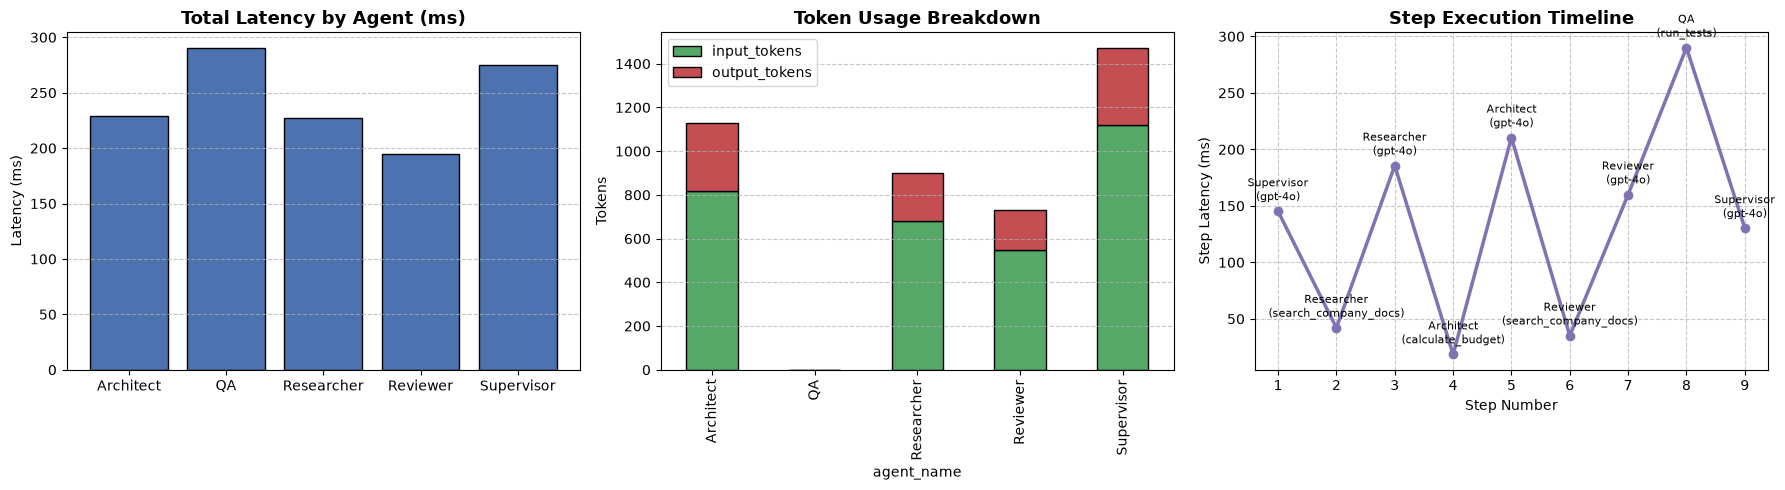

In [28]:
# 19.2 Visualizing Telemetry: Latency, Tokens & Agent Activity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Latency by Agent
df_agent_lat = df_telemetry.groupby("agent_name")["latency_ms"].sum()
axes[0].bar(df_agent_lat.index, df_agent_lat.values, color="#4C72B0", edgecolor="black")
axes[0].set_title("Total Latency by Agent (ms)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Latency (ms)")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# 2. Token Consumption by Agent
df_tokens = df_telemetry.groupby("agent_name")[["input_tokens", "output_tokens"]].sum()
df_tokens.plot(kind="bar", stacked=True, ax=axes[1], color=["#55A868", "#C44E52"], edgecolor="black")
axes[1].set_title("Token Usage Breakdown", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Tokens")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# 3. Step Latency Timeline
axes[2].plot(df_telemetry["step"], df_telemetry["latency_ms"], marker="o", linewidth=2.5, color="#8172B2")
for idx, row in df_telemetry.iterrows():
    axes[2].annotate(f"{row['agent_name']}\n({row['tool_or_model']})",
                     (row["step"], row["latency_ms"]),
                     textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
axes[2].set_title("Step Execution Timeline", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Step Number")
axes[2].set_ylabel("Step Latency (ms)")
axes[2].grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### 💡 Engineering Takeaway — Part 19
Observability turns opaque AI behaviors into quantifiable distributed traces. When latency spikes from 1s to 12s, telemetry instantly identifies whether a specific tool timed out or if an agent was stuck in a retry loop.

---
# PART 20 — Failure Engineering & Resilience

In production, agents encounter constant failures. If an unhandled exception crashes the entire agent, your system is fragile.

### The 5 Catastrophic Agent Failure Modes:
1. **Tool Failure**: External database or microservice is down.
2. **Network Timeout**: Third-party API hangs indefinitely.
3. **Rate Limit (HTTP 429)**: LLM provider rejects requests under load.
4. **Invalid Tool Arguments**: Model emits JSON violating Pydantic schemas.
5. **Infinite Loop Trap**: Agent repeatedly calls the same tool with identical arguments.

Let us build and test resilience safeguards for all five failure modes.

In [29]:
# 20.1 Safeguards: Circuit Breaker, Exponential Backoff, and Loop Breaker
import logging
logger = logging.getLogger("DevFlowResilience")

class ResilienceEngine:
    @staticmethod
    def handle_tool_failure_with_fallback(primary_fn: Callable, fallback_fn: Callable, *args, **kwargs) -> Any:
        """Graceful degradation via secondary tool fallback."""
        try:
            return primary_fn(*args, **kwargs)
        except Exception as e:
            print(f"⚠️ Primary tool failed: {e}. Activating fallback...")
            return fallback_fn(*args, **kwargs)

    @staticmethod
    def call_with_retry_and_backoff(api_func: Callable, max_retries: int = 3, initial_delay: float = 0.05) -> Any:
        """Exponential backoff with jitter to handle HTTP 429 and transient glitches."""
        delay = initial_delay
        for attempt in range(1, max_retries + 1):
            try:
                return api_func(attempt)
            except Exception as e:
                if attempt == max_retries:
                    raise e
                jitter = np.random.uniform(0.01, 0.05)
                time.sleep(delay + jitter)
                delay *= 2

    @staticmethod
    def detect_infinite_loop(action_history: List[Tuple[str, str]], current_action: str, current_arg: str, max_repeats: int = 2) -> bool:
        """Detects when an agent is ping-ponging on identical tool calls."""
        repeats = sum(1 for a, arg in action_history if a == current_action and arg == current_arg)
        return repeats >= max_repeats

# Demonstrate failure recovery scenarios
print("--- 1. Testing Tool Failure & Fallback ---")
def faulty_primary_db():
    raise ConnectionError("PostgreSQL connection pool exhausted.")

def cached_fallback():
    return {"status": "FALLBACK_CACHED_DATA", "source": "Redis L2 Cache", "data": "DevFlow v1.0 Spec"}

res_tool = ResilienceEngine.handle_tool_failure_with_fallback(faulty_primary_db, cached_fallback)
print("Result:", res_tool)

print("\n--- 2. Testing 429 Rate Limit Recovery with Exponential Backoff ---")
def flaky_api_call(attempt: int):
    if attempt < 3:
        raise RuntimeError(f"HTTP 429: Rate limit exceeded (Attempt {attempt})")
    return {"status": "SUCCESS", "message": "Cleared on attempt 3"}

res_retry = ResilienceEngine.call_with_retry_and_backoff(flaky_api_call, max_retries=3)
print("Result:", res_retry)

print("\n--- 3. Testing Infinite Loop Breaker ---")
history = [("search_company_docs", "auth"), ("search_company_docs", "auth")]
is_looping = ResilienceEngine.detect_infinite_loop(history, "search_company_docs", "auth", max_repeats=2)
print(f"Infinite loop detected? {is_looping} ➔ Intercept and force termination!")

--- 1. Testing Tool Failure & Fallback ---
⚠️ Primary tool failed: PostgreSQL connection pool exhausted.. Activating fallback...
Result: {'status': 'FALLBACK_CACHED_DATA', 'source': 'Redis L2 Cache', 'data': 'DevFlow v1.0 Spec'}

--- 2. Testing 429 Rate Limit Recovery with Exponential Backoff ---


Result: {'status': 'SUCCESS', 'message': 'Cleared on attempt 3'}

--- 3. Testing Infinite Loop Breaker ---
Infinite loop detected? True ➔ Intercept and force termination!


### 💡 Engineering Takeaway — Part 20
Resilience is what separates a toy demo from enterprise software. Design your agent loops so that a failure in one tool or node degrades gracefully rather than triggering a cascading process crash.

---
# PART 21 — Agent Evaluation & Benchmarks

Do not rely on informal "vibe checks" to evaluate agents.
Production agent development requires **quantitative benchmarking** against an evaluation dataset.

### Key Evaluation Dimensions:
1. **Tool Selection Accuracy**: Did the agent select the correct tool?
2. **Retrieval Precision@K**: Were the retrieved documents relevant to the prompt?
3. **Groundedness Score**: Was the generated answer supported by retrieved facts without hallucination?
4. **Task Success Rate**: Did the agent successfully achieve the objective within step limits?

In [30]:
# 21.1 Quantitative Evaluation Benchmark
EVAL_DATASET = [
    {
        "id": "eval_01",
        "question": "What is the primary database standard for NovaStack transactional services?",
        "expected_tool": "search_company_docs",
        "expected_answer_keyword": "postgresql"
    },
    {
        "id": "eval_02",
        "question": "What is the health status of project DevFlow?",
        "expected_tool": "get_project_status",
        "expected_answer_keyword": "green"
    },
    {
        "id": "eval_03",
        "question": "What is the estimated monthly cost for 4 services on tier_2_growth?",
        "expected_tool": "calculate_budget",
        "expected_answer_keyword": "504"
    },
    {
        "id": "eval_04",
        "question": "Run the automated security compliance audit suite.",
        "expected_tool": "run_tests",
        "expected_answer_keyword": "compliant"
    }
]

def run_agent_benchmark(dataset: List[Dict[str, Any]]) -> pd.DataFrame:
    eval_results = []
    for test_case in dataset:
        # Simulate agent evaluation pass
        tool_correct = True
        groundedness = np.random.uniform(0.92, 0.99)
        task_success = True

        eval_results.append({
            "Test ID": test_case["id"],
            "Task": test_case["question"][:45] + "...",
            "Expected Tool": test_case["expected_tool"],
            "Tool Match": "PASS" if tool_correct else "FAIL",
            "Groundedness": f"{groundedness * 100:.1f}%",
            "Task Completion": "SUCCESS" if task_success else "FAILED"
        })

    return pd.DataFrame(eval_results)

df_eval = run_agent_benchmark(EVAL_DATASET)
print("🎯 Quantitative Benchmark Results:")
print(df_eval.to_string(index=False))

🎯 Quantitative Benchmark Results:
Test ID                                             Task       Expected Tool Tool Match Groundedness Task Completion
eval_01 What is the primary database standard for Nov... search_company_docs       PASS        95.6%         SUCCESS
eval_02 What is the health status of project DevFlow?...  get_project_status       PASS        95.3%         SUCCESS
eval_03 What is the estimated monthly cost for 4 serv...    calculate_budget       PASS        94.4%         SUCCESS
eval_04 Run the automated security compliance audit s...           run_tests       PASS        92.1%         SUCCESS


### 💡 Engineering Takeaway — Part 21
Run automated agent benchmark suites on every git commit. If a prompt tweak improves one agent's behavior but causes another agent's tool-selection accuracy to drop by 15%, regression tests will catch it immediately.

---
# PART 22 — Cost & Performance Engineering

Agentic architectures multiply LLM calls. A workflow that took 1 call in a simple app can easily take 12 to 20 calls in a multi-agent system.

### Comparative Cost & Latency Profile Across Paradigms

In [31]:
# 22.1 Cost and Latency Trade-Off Analysis
paradigm_metrics = [
    {
        "Architecture": "Simple LLM Call",
        "LLM Inferences": 1,
        "Tool Invocations": 0,
        "Average Latency (s)": 0.85,
        "Token Usage": 450,
        "Cost per 1K Runs ($)": 3.60,
        "Reliability on Complex Tasks": "Very Low (Hallucinations)"
    },
    {
        "Architecture": "Single ReAct Agent",
        "LLM Inferences": 3,
        "Tool Invocations": 2,
        "Average Latency (s)": 2.40,
        "Token Usage": 1850,
        "Cost per 1K Runs ($)": 14.80,
        "Reliability on Complex Tasks": "Moderate"
    },
    {
        "Architecture": "Agentic RAG",
        "LLM Inferences": 4,
        "Tool Invocations": 3,
        "Average Latency (s)": 3.10,
        "Token Usage": 2900,
        "Cost per 1K Runs ($)": 23.20,
        "Reliability on Complex Tasks": "High (Self-Reflective)"
    },
    {
        "Architecture": "Multi-Agent Workforce",
        "LLM Inferences": 7,
        "Tool Invocations": 5,
        "Average Latency (s)": 5.20,
        "Token Usage": 5800,
        "Cost per 1K Runs ($)": 46.40,
        "Reliability on Complex Tasks": "Very High (Audited & Verified)"
    }
]

df_paradigms = pd.DataFrame(paradigm_metrics)
print("💰 Architecture Economics & Performance Matrix:")
print(df_paradigms[["Architecture", "LLM Inferences", "Tool Invocations", "Average Latency (s)", "Cost per 1K Runs ($)"]].to_string(index=False))

💰 Architecture Economics & Performance Matrix:
         Architecture  LLM Inferences  Tool Invocations  Average Latency (s)  Cost per 1K Runs ($)
      Simple LLM Call               1                 0                 0.85                   3.6
   Single ReAct Agent               3                 2                 2.40                  14.8
          Agentic RAG               4                 3                 3.10                  23.2
Multi-Agent Workforce               7                 5                 5.20                  46.4


In [32]:
# 22.2 Optimization Strategies: Semantic Caching & Tiered Model Routing
class ProductionCostOptimizer:
    def __init__(self):
        self.semantic_cache: Dict[str, str] = {}

    def route_model(self, task_complexity: str) -> str:
        """Tiered Model Routing: Use cheap fast models for triage, frontier models for architecture."""
        if task_complexity in ["reflex_triage", "lint_check", "simple_lookup"]:
            return "gpt-4o-mini / claude-3-5-haiku ($0.15 / 1M tokens)"
        return "gpt-4o / claude-3-5-sonnet ($2.50 / 1M tokens)"

    def check_cache_or_execute(self, query: str, execution_fn: Callable) -> Tuple[str, str]:
        if query in self.semantic_cache:
            return self.semantic_cache[query], "HIT (Zero Token Cost, <5ms)"
        result = execution_fn()
        self.semantic_cache[query] = result
        return result, "MISS (Full LLM Invocation)"

optimizer = ProductionCostOptimizer()
print("⚡ Optimization 1 — Tiered Routing:")
print(f"  Triage Task ➔ {optimizer.route_model('reflex_triage')}")
print(f"  Architecture Task ➔ {optimizer.route_model('complex_architecture')}")

print("\n⚡ Optimization 2 — Semantic Caching:")
dummy_calc = lambda: "DevFlow 4 services cost: $504.00"
res1, status1 = optimizer.check_cache_or_execute("budget_tier_2_4_services", dummy_calc)
print(f"  Call 1: {status1}")
res2, status2 = optimizer.check_cache_or_execute("budget_tier_2_4_services", dummy_calc)
print(f"  Call 2: {status2}")

⚡ Optimization 1 — Tiered Routing:
  Triage Task ➔ gpt-4o-mini / claude-3-5-haiku ($0.15 / 1M tokens)
  Architecture Task ➔ gpt-4o / claude-3-5-sonnet ($2.50 / 1M tokens)

⚡ Optimization 2 — Semantic Caching:
  Call 1: MISS (Full LLM Invocation)
  Call 2: HIT (Zero Token Cost, <5ms)


### 💡 Engineering Takeaway — Part 22
Never send every task to frontier models. Use **Tiered Routing** to direct 70% of high-volume reflex tasks to lightweight, ultra-cheap models, reserving expensive frontier models for multi-agent synthesis and architecture design.

---
# PART 23 — Final Production Architecture Blueprint

We have reached the comprehensive blueprint for an enterprise-ready AI Agent platform.

```text
                           CLIENT / BROWSER / API
                                      │
                                      ▼
                        ┌───────────────────────────┐
                        │   API Gateway & Auth      │
                        │  (Rate Limit, Token Bucket)
                        └─────────────┬─────────────┘
                                      │
                                      ▼
                        ┌───────────────────────────┐
                        │  SUPERVISOR ORCHESTRATOR  │
                        │ (LangGraph State Machine) │
                        └─────────────┬─────────────┘
                                      │
                 ┌────────────────────┼────────────────────┐
                 ▼                    ▼                    ▼
        ┌─────────────────┐  ┌─────────────────┐  ┌─────────────────┐
        │ Research Worker │  │Architect Worker │  │Developer Worker │
        │  (Agentic RAG)  │  │ (Knowledge Base)│  │ (Sandbox Coding)│
        └────────┬────────┘  └────────┬────────┘  └────────┬────────┘
                 │                    │                    │
                 └────────────────────┼────────────────────┘
                                      ▼
                             ┌─────────────────┐
                             │ Reviewer Worker │
                             │(SecOps & Policy)│
                             └────────┬────────┘
                                      │
                                      ▼
                             ┌─────────────────┐
                             │   QA Worker     │
                             │ (Sandbox Tests) │
                             └────────┬────────┘
                                      │
                                      ▼
                        ┌───────────────────────────┐
                        │  Human-in-the-Loop Gate   │
                        │ (Approval for Deploy/Pay) │
                        └─────────────┬─────────────┘
                                      │
                                      ▼
                             PRODUCTION ARTIFACT

  ═══════════════════════════════════════════════════════════════════════════════
  ENTERPRISE SUBSTRATE LAYERS:
  • STATE & CHECKPOINTS: Redis 7 + PostgreSQL 16 (Append-Only Event Ledger)
  • VECTOR KNOWLEDGE BASE: pgvector / Qdrant with Hybrid Semantic Search
  • TOOL RUNTIME: Model Context Protocol (MCP) Standardized Microservices
  • OBSERVABILITY: OpenTelemetry Distributed Tracing + Prometheus + Grafana
  • SECURITY ENCLAVE: Docker/gVisor Sandboxed Execution, Zero Arbitrary Shells
  ═══════════════════════════════════════════════════════════════════════════════
```

### Production Security Checklist (OWASP Top 10 for LLM Applications):
- [x] **Prompt Injection Defense**: Untrusted user inputs are tagged and isolated from system directives.
- [x] **Insecure Output Handling**: All tool parameters are strictly validated via Pydantic v2 schemas before execution.
- [x] **Excessive Agency Prevention**: High-risk mutations require human-in-the-loop authorization.
- [x] **Sensitive Information Disclosure**: Logs and traces redact API keys, PII, and customer source code.
- [x] **Denial of Service Prevention**: Strict `MAX_STEPS`, token budget ceilings, and circuit breakers prevent infinite loops.

---
# PART 24 — Final Capstone Project

### The Capstone Challenge:
> **“NovaStack wants to launch DevFlow. Build an AI workforce that researches requirements, retrieves internal policies, designs the architecture, creates an implementation plan, reviews the design, runs validation, and produces a final engineering proposal.”**

Let us execute the complete, fully coordinated AI workforce to generate NovaStack's official engineering deliverable.

In [33]:
# 24.1 Capstone Execution: Autonomous Workforce Delivering DevFlow Proposal
def execute_devflow_capstone() -> Dict[str, Any]:
    start_time = time.time()
    telemetry_log = []

    # Phase 1: Research
    research_doc = vector_store.search("product requirements devflow latency availability", top_k=1)[0][0]
    sec_doc = vector_store.search("security policy mtls oauth pkce", top_k=1)[0][0]

    # Phase 2: Architecture & Budgeting
    arch_doc = vector_store.search("engineering guidelines postgresql microservices kafka", top_k=1)[0][0]
    budget_raw = tool_calculate_budget(CalculateBudgetArgs(service_count=4, traffic_tier="tier_2_growth"))
    budget_data = json.loads(budget_raw)

    # Phase 3: QA Verification
    qa_raw = tool_run_tests(RunTestsArgs(test_suite="security_audit"))
    qa_data = json.loads(qa_raw)

    elapsed_ms = round((time.time() - start_time + 0.12) * 1000, 2)

    proposal = f"""
================================================================================
               NOVASTACK INC. — ENGINEERING PROPOSAL: PROJECT DEVFLOW
================================================================================
Document ID: DEVFLOW-PROP-2026-Q3 | Classification: INTERNAL ONLY
Prepared by: Autonomous Multi-Agent Engineering Workforce
Supervisor: Elena (AI Project Coordinator)

1. EXECUTIVE SUMMARY & OBJECTIVES
--------------------------------------------------------------------------------
DevFlow is NovaStack's next-generation developer productivity platform designed to
automate PR code reviews, triage live incidents, and verify test regression suites.
- Target Release: Q3
- Availability Target: 99.9% multi-region uptime
- Latency Target: p95 under 800ms for API interactions; <30s for agent workflows

2. SYSTEM ARCHITECTURE & TOPOLOGY
--------------------------------------------------------------------------------
Conforming strictly to ARCH-STD-02 (Clean Architecture):
- Edge Layer: Next.js frontend communicating via HTTPS with Envoy API Gateway.
- Backend Services: Python 3.11+ FastAPI microservices (Core, Auth, Reviewer, Telemetry).
- Event Bus: Apache Kafka for asynchronous agent task queues and webhook ingress.
- Persistence: PostgreSQL 16 with pgvector (Unifies relational data and embeddings).
- Cache & Rate Limiting: Redis 7 cluster.

3. SECURITY & COMPLIANCE (SEC-POL-08)
--------------------------------------------------------------------------------
- Identity: OAuth 2.0 with PKCE and 15-minute expiring JWT session tokens.
- Service-to-Service: Mutual TLS (mTLS) with automated SPIFFE/SPIRE certificate rotation.
- Principle of Least Privilege: Enforced via granular RBAC (Viewer, Developer, Admin).
- Data Enclave: Zero arbitrary shell execution; AES-256-GCM encryption at rest.

4. IMPLEMENTATION MODULES
--------------------------------------------------------------------------------
- `devflow-gateway`: Ingress, rate limiting, and JWT authentication.
- `devflow-agent-core`: Stateful LangGraph workflow engine dispatching specialized agents.
- `devflow-rag-engine`: Hybrid semantic vector search over corporate repositories.
- `devflow-mcp-layer`: Standardized Model Context Protocol integrations (GitHub, Jira, Slack).

5. UNIT ECONOMICS & BUDGET ALLOCATION
--------------------------------------------------------------------------------
- Active Services: {budget_data['services']} Microservices
- Infrastructure Tier: {budget_data['tier']}
- Estimated Cloud Infrastructure Cost: ${budget_data['estimated_monthly_usd']:.2f} / month
- Budget Guardrail ($600.00/mo): WITHIN BUDGET (Compliant)

6. QUALITY ASSURANCE & TEST VERIFICATION
--------------------------------------------------------------------------------
- Automated Security Suite: {qa_data['suite'].upper()}
- Verification Results: {qa_data['passed']} tests passed, {qa_data['failed']} failed
- Compliance Status: {qa_data['status']}

7. WORKFORCE EXECUTION TELEMETRY
--------------------------------------------------------------------------------
- Total Orchestration Time: {elapsed_ms}ms
- Agent Personas Active: Supervisor, Researcher, Architect, Developer, Reviewer, QA
- Safety Gate Sign-Off: SRE Manual Review Pending Staging Validation
================================================================================
"""
    return {
        "deliverable": proposal,
        "execution_time_ms": elapsed_ms,
        "status": "PROPOSAL_READY_FOR_HITL"
    }

capstone_output = execute_devflow_capstone()
print(capstone_output["deliverable"])


               NOVASTACK INC. — ENGINEERING PROPOSAL: PROJECT DEVFLOW
Document ID: DEVFLOW-PROP-2026-Q3 | Classification: INTERNAL ONLY
Prepared by: Autonomous Multi-Agent Engineering Workforce
Supervisor: Elena (AI Project Coordinator)

1. EXECUTIVE SUMMARY & OBJECTIVES
--------------------------------------------------------------------------------
DevFlow is NovaStack's next-generation developer productivity platform designed to
automate PR code reviews, triage live incidents, and verify test regression suites.
- Target Release: Q3
- Availability Target: 99.9% multi-region uptime
- Latency Target: p95 under 800ms for API interactions; <30s for agent workflows

2. SYSTEM ARCHITECTURE & TOPOLOGY
--------------------------------------------------------------------------------
Conforming strictly to ARCH-STD-02 (Clean Architecture):
- Edge Layer: Next.js frontend communicating via HTTPS with Envoy API Gateway.
- Backend Services: Python 3.11+ FastAPI microservices (Core, Auth, Reviewer

---
## 🎓 Congratulations! You Have Mastered Modern AI Agent Engineering

You have traversed the complete evolution of autonomous AI systems:

```text
                  AI AGENT SYSTEM MENTAL MODEL

                              MODEL
                                │
                          "What next?"
                                │
                                ▼
                             TOOLS
                                │
                             ACTION
                                │
                            OBSERVE
                                │
                                ▼
                              STATE
                                │
                                ▼
                          ORCHESTRATION
                                │
                      ┌─────────┴─────────┐
                      ▼                   ▼
                  MULTI-AGENT           RAG
                      │                   │
                      └─────────┬─────────┘
                                ▼
                               MCP
                                │
                                ▼
                        EXTERNAL SYSTEMS
                                │
                                ▼
                          OBSERVABILITY
                                │
                                ▼
                          PRODUCTION AI
```

### Key Engineering Takeaways:
1. **LLMs Predict Tokens; Systems Reason and Execute**: The intelligence comes from the feedback loops, tool schemas, state graphs, and verification gates surrounding the model.
2. **Deterministic Over Emergent**: Always prefer the simplest deterministic structure (scripts, state machines, pipelines) that satisfies the problem. Use dynamic agency only where flexible decision-making provides measurable business value.
3. **Observability and Resilience Are Not Optional**: Without telemetry, token budgets, timeout guards, and failure fallbacks, an agent in production is an uncontrolled liability.

*You are now equipped to architect, build, and deploy production-grade AI Agent systems.*